In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data_high=pd.read_excel(r'D:\AI4polymer\cocrystal design\Data-0320\Multimodal68\ESDescriptor-Multimodal68.xlsx')
data_low=pd.read_excel(r'D:\AI4polymer\cocrystal design\Data-0320\Batch633\ESDescriptor-Batch633.xlsx')

In [3]:
data_high

,ID,Original_SMILES,es1_ev,fs1,et1_ev,delta_est_ev,min_abs_s1_tn_ev,d_index_ang,t_index_ang
0,1,FC(C(F)=C(C1=NSN=C12)C3=CC=C(C4=CC=C(N(C(C=C5)...,1.730,1.276655,1.165,0.565,0.055,0.674,-3.892
1,2,FC(C(F)=C(C1=NSN=C12)C3=CC(CC(CCCC)CC)=C(C4=CC...,1.780,0.977038,1.236,0.544,0.080,3.194,1.336
2,3,O=C1C(C2=C(C3=CC=C(C4=CC=C(N(C5=CC=CC=C5)C6=CC...,2.065,2.414549,0.973,1.092,0.089,0.123,-1.741
3,4,O=C1C(C2=C(/C=C/C3=CC=C(N(C4=CC=CC=C4)C5=CC=CC...,2.052,2.772493,0.808,1.244,0.098,0.836,-4.734
4,5,O=C1C(C2=C(/C=C/C3=CC=C(C=C3)/C(C4=CC=CC=C4)=C...,1.729,1.326939,0.832,0.897,0.129,9.051,4.147
...,...,...,...,...,...,...,...,...,...
63,64,O=C(C(C=C1Cl)=C(C=C1Cl)C/2=C(C#N)/C#N)C2=C/C3=...,0.690,0.000340,0.687,0.003,0.003,12.300,9.572
64,65,O=C(C1=C2C=C(F)C(F)=C1)C(/C2=C(C#N)\C#N)=C\C3=...,0.702,0.000285,0.700,0.002,0.002,12.111,9.432
65,66,O=C(C(C=C1Cl)=C(C=C1Cl)C/2=C(C#N)/C#N)C2=C/C3=...,0.709,0.020307,0.693,0.016,0.016,11.780,9.145
66,67,O=C(C1=C2C=C(F)C(F)=C1)C(/C2=C(C#N)\C#N)=C\C3=...,0.787,0.045188,0.755,0.032,0.032,11.743,9.177


In [4]:
properties = ['es1_ev', 'fs1', 'et1_ev', 'delta_est_ev', 'min_abs_s1_tn_ev', 'd_index_ang', 't_index_ang']

cols_needed = ['ID'] + properties

data_high = data_high[cols_needed]
data_low = data_low[cols_needed]

# === 按 ID 合并（inner 保证只有 68 个重叠分子）===
df = pd.merge(
    data_high, data_low,
    on='ID',
    suffixes=('_high', '_low'),
    how='inner'
)

print(f"Number of matched molecules: {len(df)}")

Number of matched molecules: 68


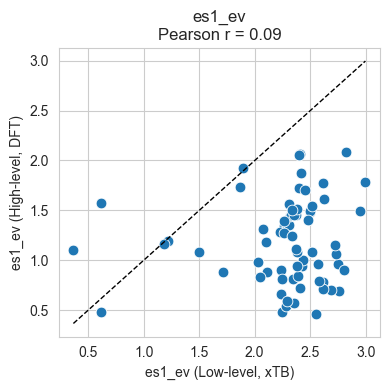

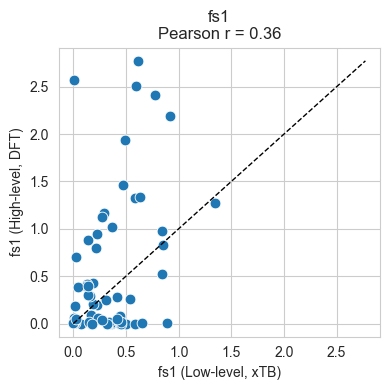

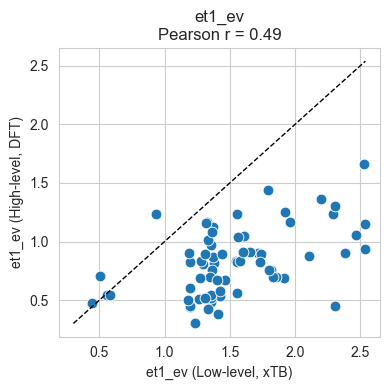

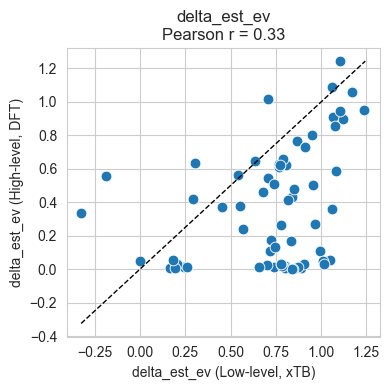

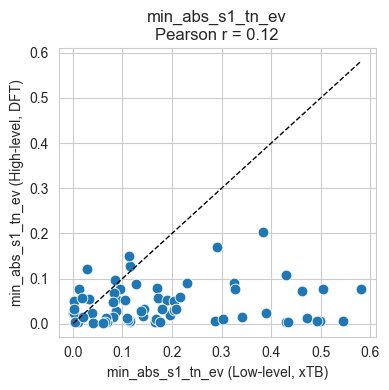

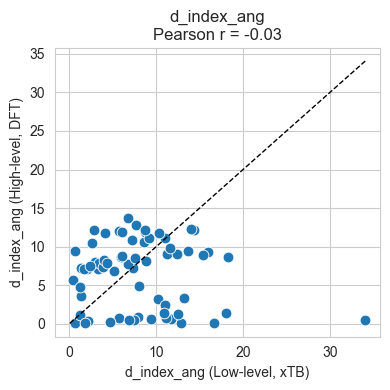

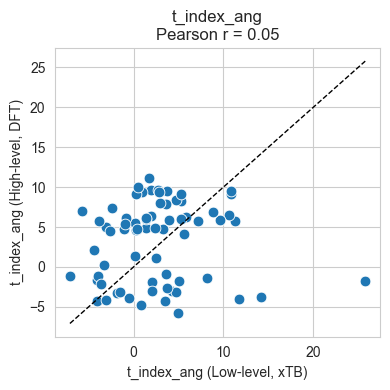

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

sns.set_style("whitegrid")

for prop in properties:
    x = df[f'{prop}_low']
    y = df[f'{prop}_high']
    
    r, _ = pearsonr(x, y)

    plt.figure(figsize=(4, 4))
    sns.scatterplot(x=x, y=y, s=60)
    
    # 1:1 line
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1)

    plt.xlabel(f'{prop} (Low-level, xTB)')
    plt.ylabel(f'{prop} (High-level, DFT)')
    plt.title(f'{prop}\nPearson r = {r:.2f}')
    plt.tight_layout()
    plt.show()


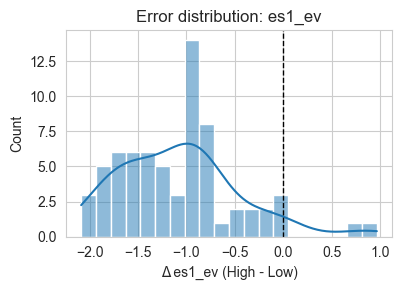

es1_ev: mean Δ = -1.080, std Δ = 0.624, MAE = 1.131


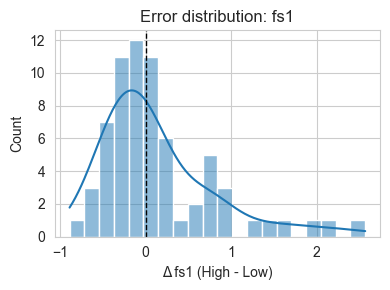

fs1: mean Δ = 0.141, std Δ = 0.681, MAE = 0.467


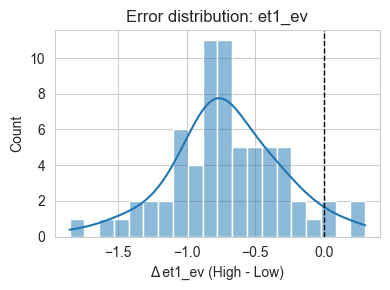

et1_ev: mean Δ = -0.710, std Δ = 0.407, MAE = 0.726


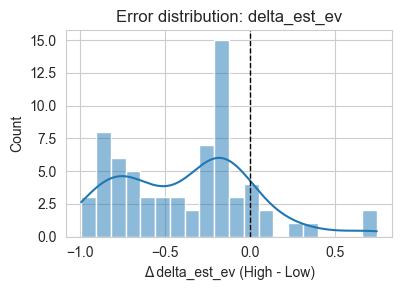

delta_est_ev: mean Δ = -0.370, std Δ = 0.390, MAE = 0.442


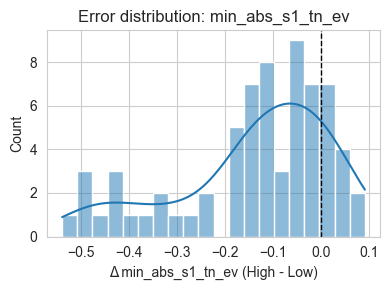

min_abs_s1_tn_ev: mean Δ = -0.140, std Δ = 0.160, MAE = 0.152


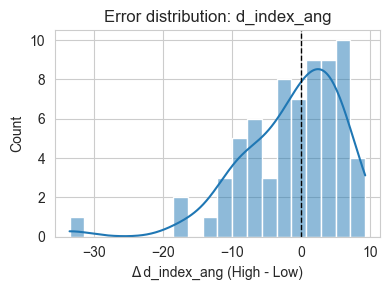

d_index_ang: mean Δ = -1.383, std Δ = 7.377, MAE = 5.489


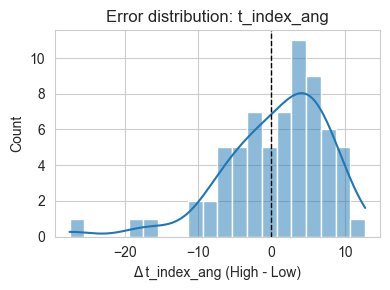

t_index_ang: mean Δ = 0.668, std Δ = 7.131, MAE = 5.577


In [6]:
for prop in properties:
    df[f'delta_{prop}'] = df[f'{prop}_high'] - df[f'{prop}_low']

    # ===== 统计量 =====
    mean_delta = df[f'delta_{prop}'].mean()
    std_delta = df[f'delta_{prop}'].std()
    mae = df[f'delta_{prop}'].abs().mean()   # ← MAE

    # ===== 画分布 =====
    plt.figure(figsize=(4, 3))
    sns.histplot(df[f'delta_{prop}'], bins=20, kde=True)
    plt.axvline(0, color='k', linestyle='--', lw=1)
    
    plt.xlabel(f'Δ {prop} (High - Low)')
    plt.title(f'Error distribution: {prop}')
    plt.tight_layout()
    plt.show()

    # ===== 打印 =====
    print(
        f"{prop}: mean Δ = {mean_delta:.3f}, "
        f"std Δ = {std_delta:.3f}, "
        f"MAE = {mae:.3f}"
    )

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.linear_model import LinearRegression

for prop in properties:
    X = df[[f'{prop}_low']].values
    y = df[f'{prop}_high'].values

    lr = LinearRegression().fit(X, y)
    y_pred = lr.predict(X)

    mae = mean_absolute_error(y, y_pred)
    mse = mean_squared_error(y, y_pred)   # 不用 squared 参数
    rmse = np.sqrt(mse)

    print(f'\n{prop}')
    print(f'  y = {lr.coef_[0]:.3f} * x + {lr.intercept_:.3f}')
    print(f'  MAE = {mae:.3f}, RMSE = {rmse:.3f}')



es1_ev
  y = 0.076 * x + 1.018
  MAE = 0.354, RMSE = 0.416

fs1
  y = 0.959 * x + 0.155
  MAE = 0.501, RMSE = 0.675

et1_ev
  y = 0.306 * x + 0.357
  MAE = 0.199, RMSE = 0.248

delta_est_ev
  y = 0.363 * x + 0.097
  MAE = 0.292, RMSE = 0.330

min_abs_s1_tn_ev
  y = 0.032 * x + 0.038
  MAE = 0.034, RMSE = 0.043

d_index_ang
  y = -0.027 * x + 6.571
  MAE = 3.886, RMSE = 4.376

t_index_ang
  y = 0.047 * x + 3.165
  MAE = 4.415, RMSE = 4.907


### 1. es1_ev

In [8]:
df

,ID,es1_ev_high,fs1_high,et1_ev_high,delta_est_ev_high,min_abs_s1_tn_ev_high,d_index_ang_high,t_index_ang_high,es1_ev_low,fs1_low,...,min_abs_s1_tn_ev_low,d_index_ang_low,t_index_ang_low,delta_es1_ev,delta_fs1,delta_et1_ev,delta_delta_est_ev,delta_min_abs_s1_tn_ev,delta_d_index_ang,delta_t_index_ang
0,1,1.730,1.276655,1.165,0.565,0.055,0.674,-3.892,1.8680,1.348143,...,0.0320,1.265,-0.559,-0.1380,-0.071488,-0.1600,0.0220,0.0230,-0.591,-3.333
1,2,1.780,0.977038,1.236,0.544,0.080,3.194,1.336,2.9974,0.837642,...,0.1697,10.251,0.135,-1.2174,0.139396,-1.0547,-0.1627,-0.0897,-7.057,1.201
2,3,2.065,2.414549,0.973,1.092,0.089,0.123,-1.741,2.4095,0.778946,...,0.1268,12.881,5.069,-0.3445,1.635603,-0.3791,0.0346,-0.0378,-12.758,-6.810
3,4,2.052,2.772493,0.808,1.244,0.098,0.836,-4.734,2.4032,0.618219,...,0.0852,7.942,0.808,-0.3512,2.154274,-0.4899,0.1387,0.0128,-7.106,-5.542
4,5,1.729,1.326939,0.832,0.897,0.129,9.051,4.147,2.3973,0.583616,...,0.1155,11.190,5.608,-0.6683,0.743323,-0.4443,-0.2240,0.0135,-2.139,-1.461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,64,0.690,0.000340,0.687,0.003,0.003,12.300,9.572,2.7555,0.439320,...,0.0643,14.030,10.820,-2.0655,-0.438980,-1.2262,-0.8393,-0.0613,-1.730,-1.248
64,65,0.702,0.000285,0.700,0.002,0.002,12.111,9.432,2.6917,0.448376,...,0.0611,8.731,2.793,-1.9897,-0.448091,-1.1520,-0.8377,-0.0591,3.380,6.639
65,66,0.709,0.020307,0.693,0.016,0.016,11.780,9.145,2.6141,0.457535,...,0.0213,10.342,5.333,-1.9051,-0.437228,-1.1383,-0.7668,-0.0053,1.438,3.812
66,67,0.787,0.045188,0.755,0.032,0.032,11.743,9.177,2.5807,0.415593,...,0.0031,4.137,0.293,-1.7937,-0.370405,-1.0497,-0.7440,0.0289,7.606,8.884


In [9]:
import numpy as np
import pandas as pd
# Δ label
df['delta_es1'] = df['es1_ev_high'] - df['es1_ev_low']
df['delta_fs1'] = df['fs1_high'] - df['fs1_low']
df['delta_et1'] = df['et1_ev_high'] - df['et1_ev_low']
df['delta_delta_est'] = df['delta_est_ev_high'] - df['delta_est_ev_low']
df['delta_min_abs_s1_tn'] = df['min_abs_s1_tn_ev_high'] - df['min_abs_s1_tn_ev_low']
df['delta_d_index'] = df['d_index_ang_high'] - df['d_index_ang_low']
df['delta_t_index'] = df['t_index_ang_high'] - df['t_index_ang_low']

In [10]:
df_high_SMILES=pd.read_excel(r'D:\AI4polymer\cocrystal design\Data-0320\Multimodal68-SMILES+Label.xlsx')
df_low_SMILES=pd.read_excel(r'D:\AI4polymer\cocrystal design\Data-0320\Batch633_SMILES+Label.xlsx')
df['smiles']=df_high_SMILES['Original_SMILES']

In [11]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# =========================
# 0) Morgan fingerprint with frequency
# =========================
def get_Morgan_fingerprint_frequency(smi, radius=3, nBits=2048):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        info = {}
        _ = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits, bitInfo=info)
        keys = list(info.keys())
        frq = [len(v) for v in info.values()]
        mff = [0] * nBits
        for k, v in zip(keys, frq):
            mff[k] = v
        return mff
    except:
        return None

# =========================
# 1) 准备数据：df 必须有 smiles
# =========================
df["morgan_fp_with_freq"] = df["smiles"].apply(get_Morgan_fingerprint_frequency)
df = df.dropna(subset=["morgan_fp_with_freq"]).reset_index(drop=True)

# 统一成 numpy（避免 list/None）
fingerprints_all = np.array(df["morgan_fp_with_freq"].tolist(), dtype=float)
y_all = df["delta_es1"].values.astype(float)
es1_low_all = df["es1_ev_low"].values.astype(float)

# =========================
# 2) 先做 90/10 split（test 永远不参与特征选择 & 训练）
# =========================
idx = np.arange(len(df))
train_idx, test_idx = train_test_split(
    idx,
    test_size=0.10,
    random_state=42,
    shuffle=True
)

fp_train_full = fingerprints_all[train_idx]
fp_test = fingerprints_all[test_idx]

y_train_full = y_all[train_idx]
y_test = y_all[test_idx]

es1_train_full = es1_low_all[train_idx]
es1_test = es1_low_all[test_idx]

# =========================
# 3) 只用 90% train 计算 top_indices（避免 test leakage）
# =========================
nonzero_frequency = np.count_nonzero(fp_train_full, axis=0) / fp_train_full.shape[0]
top_indices = np.argsort(nonzero_frequency)[-100:]   # top100

# 组装 train_full / test 的特征
fp_train_top_full = fp_train_full[:, top_indices]
fp_test_top = fp_test[:, top_indices]

X_train_full = np.hstack([es1_train_full.reshape(-1, 1), fp_train_top_full])
X_test = np.hstack([es1_test.reshape(-1, 1), fp_test_top])

# =========================
# 4) 在 90% train 上做 5-fold CV（每折：fit scaler+gpr → predict）
# =========================
kernel = (
    C(1.0, (1e-2, 1e2)) *
    RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) +
    WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_true, cv_pred = [], []

for tr_i, va_i in kf.split(X_train_full):
    X_tr, X_va = X_train_full[tr_i], X_train_full[va_i]
    y_tr, y_va = y_train_full[tr_i], y_train_full[va_i]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_va_s = scaler.transform(X_va)

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
    )

    gpr.fit(X_tr_s, y_tr)
    y_hat = gpr.predict(X_va_s)

    cv_true.append(y_va)
    cv_pred.append(y_hat)

cv_true = np.concatenate(cv_true)
cv_pred = np.concatenate(cv_pred)

cv_mae = mean_absolute_error(cv_true, cv_pred)
cv_rmse = np.sqrt(mean_squared_error(cv_true, cv_pred))
cv_r2 = r2_score(cv_true, cv_pred)

print("===== 5-fold CV on 90% train =====")
print(f"MAE  = {cv_mae:.2f} kJ/mol")
print(f"RMSE = {cv_rmse:.2f} kJ/mol")
print(f"R²   = {cv_r2:.3f}")

# =========================
# 5) 用 90% train 全量训练最终模型（scaler + gpr）
# =========================
final_scaler = StandardScaler()
X_train_full_s = final_scaler.fit_transform(X_train_full)

final_gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)
final_gpr.fit(X_train_full_s, y_train_full)

# 在 10% test 上做一次最终评估（完全独立）
X_test_s = final_scaler.transform(X_test)
y_test_hat = final_gpr.predict(X_test_s)

test_mae = mean_absolute_error(y_test, y_test_hat)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_hat))
test_r2 = r2_score(y_test, y_test_hat)

print("\n===== Hold-out 10% Test (trained on 90%) =====")
print(f"MAE  = {test_mae:.2f} kJ/mol")
print(f"RMSE = {test_rmse:.2f} kJ/mol")
print(f"R²   = {test_r2:.3f}")


[13:20:36] DEPRECATION WARNING: please use MorganGenerator
[13:20:36] DEPRECATION WARNING: please use MorganGenerator
[13:20:36] DEPRECATION WARNING: please use MorganGenerator
[13:20:36] DEPRECATION WARNING: please use MorganGenerator
[13:20:36] DEPRECATION WARNING: please use MorganGenerator
[13:20:36] DEPRECATION WARNING: please use MorganGenerator
[13:20:36] DEPRECATION WARNING: please use MorganGenerator
[13:20:36] DEPRECATION WARNING: please use MorganGenerator
[13:20:36] DEPRECATION WARNING: please use MorganGenerator
[13:20:36] DEPRECATION WARNING: please use MorganGenerator
[13:20:36] DEPRECATION WARNING: please use MorganGenerator
[13:20:36] DEPRECATION WARNING: please use MorganGenerator
[13:20:36] DEPRECATION WARNING: please use MorganGenerator
[13:20:36] DEPRECATION WARNING: please use MorganGenerator
[13:20:36] DEPRECATION WARNING: please use MorganGenerator
[13:20:36] DEPRECATION WARNING: please use MorganGenerator
[13:20:36] DEPRECATION WARNING: please use MorganGenerat

===== 5-fold CV on 90% train =====
MAE  = 0.33 kJ/mol
RMSE = 0.50 kJ/mol
R²   = 0.390

===== Hold-out 10% Test (trained on 90%) =====
MAE  = 0.21 kJ/mol
RMSE = 0.27 kJ/mol
R²   = 0.631


In [12]:
data_low

,ID,es1_ev,fs1,et1_ev,delta_est_ev,min_abs_s1_tn_ev,d_index_ang,t_index_ang
0,1,1.8680,1.348143,1.3250,0.5430,0.0320,1.265,-0.559
1,2,2.9974,0.837642,2.2907,0.7067,0.1697,10.251,0.135
2,3,2.4095,0.778946,1.3521,1.0574,0.1268,12.881,5.069
3,4,2.4032,0.618219,1.2979,1.1053,0.0852,7.942,0.808
4,5,2.3973,0.583616,1.2763,1.1210,0.1155,11.190,5.608
...,...,...,...,...,...,...,...,...
628,629,2.4056,0.603487,1.3689,1.0367,0.1172,5.362,0.145
629,630,2.3145,0.235426,1.2696,1.0449,0.1074,1.890,-3.945
630,631,2.0000,0.234473,1.2056,0.7944,0.3562,1.224,-1.151
631,632,2.0288,0.276562,1.2906,0.7382,0.2764,10.349,4.781


In [13]:
data_low['smiles']=df_low_SMILES['Original_SMILES']
data_low["morgan_fp_with_freq"] = data_low["smiles"].apply(get_Morgan_fingerprint_frequency)
data_low = data_low.dropna(subset=["morgan_fp_with_freq"]).reset_index(drop=True)
fp_low = np.array(data_low["morgan_fp_with_freq"].tolist(), dtype=float)
fp_low_top = fp_low[:, top_indices]
X_low = np.hstack([
    data_low["es1_ev"].values.astype(float).reshape(-1, 1),
    fp_low_top.astype(float)
])
X_low_s = final_scaler.transform(X_low)
delta_pred = final_gpr.predict(X_low_s)
data_low["delta_es1_pred"] = delta_pred
data_low["es1_ev_high_pred"] = data_low["es1_ev"].astype(float) + data_low["delta_es1_pred"].astype(float)

[13:20:44] DEPRECATION WARNING: please use MorganGenerator
[13:20:44] DEPRECATION WARNING: please use MorganGenerator
[13:20:44] DEPRECATION WARNING: please use MorganGenerator
[13:20:44] DEPRECATION WARNING: please use MorganGenerator
[13:20:44] DEPRECATION WARNING: please use MorganGenerator
[13:20:44] DEPRECATION WARNING: please use MorganGenerator
[13:20:44] DEPRECATION WARNING: please use MorganGenerator
[13:20:44] DEPRECATION WARNING: please use MorganGenerator
[13:20:44] DEPRECATION WARNING: please use MorganGenerator
[13:20:44] DEPRECATION WARNING: please use MorganGenerator
[13:20:44] DEPRECATION WARNING: please use MorganGenerator
[13:20:44] DEPRECATION WARNING: please use MorganGenerator
[13:20:44] DEPRECATION WARNING: please use MorganGenerator
[13:20:44] DEPRECATION WARNING: please use MorganGenerator
[13:20:44] DEPRECATION WARNING: please use MorganGenerator
[13:20:44] DEPRECATION WARNING: please use MorganGenerator
[13:20:44] DEPRECATION WARNING: please use MorganGenerat

In [14]:
data_es_new_300=pd.read_excel(r'D:\AI4polymer\cocrystal design\Data-0320\Virtual300\ESDescriptor-Virtual300.xlsx')

In [15]:
data_es_new_300["morgan_fp_with_freq"] = data_es_new_300["SMILES"].apply(get_Morgan_fingerprint_frequency)
data_es_new_300 = data_es_new_300.dropna(subset=["morgan_fp_with_freq"]).reset_index(drop=True)
fp_es_new_300 = np.array(data_es_new_300["morgan_fp_with_freq"].tolist(), dtype=float)
fp_es_new_300_top = fp_es_new_300[:, top_indices]
X_es_new_300 = np.hstack([
    data_es_new_300["es1_ev"].values.astype(float).reshape(-1, 1),
    fp_es_new_300_top.astype(float)
])
X_es_new_300_s = final_scaler.transform(X_es_new_300)
delta_pred = final_gpr.predict(X_es_new_300_s)
data_es_new_300["delta_es1_pred"] = delta_pred
data_es_new_300["es1_ev_high_pred"] = data_es_new_300["es1_ev"].astype(float) + data_es_new_300["delta_es1_pred"].astype(float)

[13:20:51] DEPRECATION WARNING: please use MorganGenerator
[13:20:51] DEPRECATION WARNING: please use MorganGenerator
[13:20:51] DEPRECATION WARNING: please use MorganGenerator
[13:20:51] DEPRECATION WARNING: please use MorganGenerator
[13:20:51] DEPRECATION WARNING: please use MorganGenerator
[13:20:51] DEPRECATION WARNING: please use MorganGenerator
[13:20:51] DEPRECATION WARNING: please use MorganGenerator
[13:20:51] DEPRECATION WARNING: please use MorganGenerator
[13:20:51] DEPRECATION WARNING: please use MorganGenerator
[13:20:51] DEPRECATION WARNING: please use MorganGenerator
[13:20:51] DEPRECATION WARNING: please use MorganGenerator
[13:20:51] DEPRECATION WARNING: please use MorganGenerator
[13:20:51] DEPRECATION WARNING: please use MorganGenerator
[13:20:51] DEPRECATION WARNING: please use MorganGenerator
[13:20:51] DEPRECATION WARNING: please use MorganGenerator
[13:20:51] DEPRECATION WARNING: please use MorganGenerator
[13:20:51] DEPRECATION WARNING: please use MorganGenerat

### 2. fs1

In [16]:
df

,ID,es1_ev_high,fs1_high,et1_ev_high,delta_est_ev_high,min_abs_s1_tn_ev_high,d_index_ang_high,t_index_ang_high,es1_ev_low,fs1_low,...,delta_d_index_ang,delta_t_index_ang,delta_es1,delta_et1,delta_delta_est,delta_min_abs_s1_tn,delta_d_index,delta_t_index,smiles,morgan_fp_with_freq
0,1,1.730,1.276655,1.165,0.565,0.055,0.674,-3.892,1.8680,1.348143,...,-0.591,-3.333,-0.1380,-0.1600,0.0220,0.0230,-0.591,-3.333,FC(C(F)=C(C1=NSN=C12)C3=CC=C(C4=CC=C(N(C(C=C5)...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,2,1.780,0.977038,1.236,0.544,0.080,3.194,1.336,2.9974,0.837642,...,-7.057,1.201,-1.2174,-1.0547,-0.1627,-0.0897,-7.057,1.201,FC(C(F)=C(C1=NSN=C12)C3=CC(CC(CCCC)CC)=C(C4=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,3,2.065,2.414549,0.973,1.092,0.089,0.123,-1.741,2.4095,0.778946,...,-12.758,-6.810,-0.3445,-0.3791,0.0346,-0.0378,-12.758,-6.810,O=C1C(C2=C(C3=CC=C(C4=CC=C(N(C5=CC=CC=C5)C6=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ..."
3,4,2.052,2.772493,0.808,1.244,0.098,0.836,-4.734,2.4032,0.618219,...,-7.106,-5.542,-0.3512,-0.4899,0.1387,0.0128,-7.106,-5.542,O=C1C(C2=C(/C=C/C3=CC=C(N(C4=CC=CC=C4)C5=CC=CC...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,5,1.729,1.326939,0.832,0.897,0.129,9.051,4.147,2.3973,0.583616,...,-2.139,-1.461,-0.6683,-0.4443,-0.2240,0.0135,-2.139,-1.461,O=C1C(C2=C(/C=C/C3=CC=C(C=C3)/C(C4=CC=CC=C4)=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,64,0.690,0.000340,0.687,0.003,0.003,12.300,9.572,2.7555,0.439320,...,-1.730,-1.248,-2.0655,-1.2262,-0.8393,-0.0613,-1.730,-1.248,O=C(C(C=C1Cl)=C(C=C1Cl)C/2=C(C#N)/C#N)C2=C/C3=...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
64,65,0.702,0.000285,0.700,0.002,0.002,12.111,9.432,2.6917,0.448376,...,3.380,6.639,-1.9897,-1.1520,-0.8377,-0.0591,3.380,6.639,O=C(C1=C2C=C(F)C(F)=C1)C(/C2=C(C#N)\C#N)=C\C3=...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
65,66,0.709,0.020307,0.693,0.016,0.016,11.780,9.145,2.6141,0.457535,...,1.438,3.812,-1.9051,-1.1383,-0.7668,-0.0053,1.438,3.812,O=C(C(C=C1Cl)=C(C=C1Cl)C/2=C(C#N)/C#N)C2=C/C3=...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
66,67,0.787,0.045188,0.755,0.032,0.032,11.743,9.177,2.5807,0.415593,...,7.606,8.884,-1.7937,-1.0497,-0.7440,0.0289,7.606,8.884,O=C(C1=C2C=C(F)C(F)=C1)C(/C2=C(C#N)\C#N)=C\C3=...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [17]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# =========================
# 0) Morgan fingerprint with frequency
# =========================
def get_Morgan_fingerprint_frequency(smi, radius=3, nBits=2048):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        info = {}
        _ = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits, bitInfo=info)
        keys = list(info.keys())
        frq = [len(v) for v in info.values()]
        mff = [0] * nBits
        for k, v in zip(keys, frq):
            mff[k] = v
        return mff
    except:
        return None

# =========================
# 1) 准备数据：df 必须有 smiles, fs1_KJmol_low, delta_fs1
# =========================
df["morgan_fp_with_freq"] = df["smiles"].apply(get_Morgan_fingerprint_frequency)
df = df.dropna(subset=["morgan_fp_with_freq"]).reset_index(drop=True)

# 统一成 numpy（避免 list/None）
fingerprints_all = np.array(df["morgan_fp_with_freq"].tolist(), dtype=float)
y_all = df["delta_fs1"].values.astype(float)
fs1_low_all = df["fs1_low"].values.astype(float)

# =========================
# 2) 先做 90/10 split（test 永远不参与特征选择 & 训练）
# =========================
idx = np.arange(len(df))
train_idx, test_idx = train_test_split(
    idx,
    test_size=0.10,
    random_state=0,
    shuffle=True
)

fp_train_full = fingerprints_all[train_idx]
fp_test = fingerprints_all[test_idx]

y_train_full = y_all[train_idx]
y_test = y_all[test_idx]

fs1_train_full = fs1_low_all[train_idx]
fs1_test = fs1_low_all[test_idx]

# =========================
# 3) 只用 90% train 计算 top_indices（避免 test leakage）
# =========================
nonzero_frequency = np.count_nonzero(fp_train_full, axis=0) / fp_train_full.shape[0]
top_indices = np.argsort(nonzero_frequency)[-100:]   # top100

# 组装 train_full / test 的特征
fp_train_top_full = fp_train_full[:, top_indices]
fp_test_top = fp_test[:, top_indices]

X_train_full = np.hstack([fs1_train_full.reshape(-1, 1), fp_train_top_full])
X_test = np.hstack([fs1_test.reshape(-1, 1), fp_test_top])

# =========================
# 4) 在 90% train 上做 5-fold CV（每折：fit scaler+gpr → predict）
# =========================
kernel = (
    C(1.0, (1e-2, 1e2)) *
    RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) +
    WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_true, cv_pred = [], []

for tr_i, va_i in kf.split(X_train_full):
    X_tr, X_va = X_train_full[tr_i], X_train_full[va_i]
    y_tr, y_va = y_train_full[tr_i], y_train_full[va_i]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_va_s = scaler.transform(X_va)

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
    )

    gpr.fit(X_tr_s, y_tr)
    y_hat = gpr.predict(X_va_s)

    cv_true.append(y_va)
    cv_pred.append(y_hat)

cv_true = np.concatenate(cv_true)
cv_pred = np.concatenate(cv_pred)

cv_mae = mean_absolute_error(cv_true, cv_pred)
cv_rmse = np.sqrt(mean_squared_error(cv_true, cv_pred))
cv_r2 = r2_score(cv_true, cv_pred)

print("===== 5-fold CV on 90% train =====")
print(f"MAE  = {cv_mae:.2f} kJ/mol")
print(f"RMSE = {cv_rmse:.2f} kJ/mol")
print(f"R²   = {cv_r2:.3f}")

# =========================
# 5) 用 90% train 全量训练最终模型（scaler + gpr）
# =========================
final_scaler = StandardScaler()
X_train_full_s = final_scaler.fit_transform(X_train_full)

final_gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)
final_gpr.fit(X_train_full_s, y_train_full)

# 在 10% test 上做一次最终评估（完全独立）
X_test_s = final_scaler.transform(X_test)
y_test_hat = final_gpr.predict(X_test_s)

test_mae = mean_absolute_error(y_test, y_test_hat)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_hat))
test_r2 = r2_score(y_test, y_test_hat)

print("\n===== Hold-out 10% Test (trained on 90%) =====")
print(f"MAE  = {test_mae:.2f} kJ/mol")
print(f"RMSE = {test_rmse:.2f} kJ/mol")
print(f"R²   = {test_r2:.3f}")


[13:20:59] DEPRECATION WARNING: please use MorganGenerator
[13:20:59] DEPRECATION WARNING: please use MorganGenerator
[13:20:59] DEPRECATION WARNING: please use MorganGenerator
[13:20:59] DEPRECATION WARNING: please use MorganGenerator
[13:20:59] DEPRECATION WARNING: please use MorganGenerator
[13:20:59] DEPRECATION WARNING: please use MorganGenerator
[13:20:59] DEPRECATION WARNING: please use MorganGenerator
[13:20:59] DEPRECATION WARNING: please use MorganGenerator
[13:20:59] DEPRECATION WARNING: please use MorganGenerator
[13:20:59] DEPRECATION WARNING: please use MorganGenerator
[13:20:59] DEPRECATION WARNING: please use MorganGenerator
[13:20:59] DEPRECATION WARNING: please use MorganGenerator
[13:20:59] DEPRECATION WARNING: please use MorganGenerator
[13:20:59] DEPRECATION WARNING: please use MorganGenerator
[13:20:59] DEPRECATION WARNING: please use MorganGenerator
[13:20:59] DEPRECATION WARNING: please use MorganGenerator
[13:20:59] DEPRECATION WARNING: please use MorganGenerat

===== 5-fold CV on 90% train =====
MAE  = 0.38 kJ/mol
RMSE = 0.60 kJ/mol
R²   = 0.244

===== Hold-out 10% Test (trained on 90%) =====
MAE  = 0.15 kJ/mol
RMSE = 0.28 kJ/mol
R²   = 0.594


In [18]:
data_low

,ID,es1_ev,fs1,et1_ev,delta_est_ev,min_abs_s1_tn_ev,d_index_ang,t_index_ang,smiles,morgan_fp_with_freq,delta_es1_pred,es1_ev_high_pred
0,1,1.8680,1.348143,1.3250,0.5430,0.0320,1.265,-0.559,FC(C(F)=C(C1=NSN=C12)C3=CC=C(C4=CC=C(N(C(C=C5)...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.146339,1.721661
1,2,2.9974,0.837642,2.2907,0.7067,0.1697,10.251,0.135,FC(C(F)=C(C1=NSN=C12)C3=CC(CC(CCCC)CC)=C(C4=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-1.215264,1.782136
2,3,2.4095,0.778946,1.3521,1.0574,0.1268,12.881,5.069,O=C1C(C2=C(C3=CC=C(C4=CC=C(N(C5=CC=CC=C5)C6=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",-0.348085,2.061415
3,4,2.4032,0.618219,1.2979,1.1053,0.0852,7.942,0.808,O=C1C(C2=C(/C=C/C3=CC=C(N(C4=CC=CC=C4)C5=CC=CC...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.360496,2.042704
4,5,2.3973,0.583616,1.2763,1.1210,0.1155,11.190,5.608,O=C1C(C2=C(/C=C/C3=CC=C(C=C3)/C(C4=CC=CC=C4)=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.518892,1.878408
...,...,...,...,...,...,...,...,...,...,...,...,...
627,629,2.4056,0.603487,1.3689,1.0367,0.1172,5.362,0.145,O=C1N(CC(C)C)C(C2=CC=C(S2)C3=CC=C(C=C3)N(C4=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",-0.179292,2.226308
628,630,2.3145,0.235426,1.2696,1.0449,0.1074,1.890,-3.945,CC1=CC=C(C=C1)N(C2=CC=C(C)C=C2)C3=CC=C(C=C3)C4...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-1.262941,1.051559
629,631,2.0000,0.234473,1.2056,0.7944,0.3562,1.224,-1.151,C1(C2=C(C=CC=C3)C3=C(N(C4=CC=C(N(C5=CC=CC=C5)C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-1.023360,0.976640
630,632,2.0288,0.276562,1.2906,0.7382,0.2764,10.349,4.781,C1(C2=C(C=CC=C3)C3=C(N(C(C=C4)=CC=C4/C(C5=CC=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.963968,1.064832


In [19]:
fp_low = np.array(data_low["morgan_fp_with_freq"].tolist(), dtype=float)
fp_low_top = fp_low[:, top_indices]
X_low = np.hstack([
    data_low["fs1"].values.astype(float).reshape(-1, 1),
    fp_low_top.astype(float)
])
X_low_s = final_scaler.transform(X_low)
delta_pred = final_gpr.predict(X_low_s)
data_low["delta_fs1_pred"] = delta_pred
data_low["fs1_high_pred"] = data_low["fs1"].astype(float) + data_low["delta_fs1_pred"].astype(float)

In [20]:
fp_es_new_300 = np.array(data_es_new_300["morgan_fp_with_freq"].tolist(), dtype=float)
fp_es_new_300_top = fp_es_new_300[:, top_indices]
X_es_new_300 = np.hstack([
    data_es_new_300["fs1"].values.astype(float).reshape(-1, 1),
    fp_es_new_300_top.astype(float)
])
X_es_new_300_s = final_scaler.transform(X_es_new_300)
delta_pred = final_gpr.predict(X_es_new_300_s)
data_es_new_300["delta_fs1_pred"] = delta_pred
data_es_new_300["fs1_high_pred"] = data_es_new_300["fs1"].astype(float) + data_es_new_300["delta_fs1_pred"].astype(float)

### 3. et1

In [21]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# =========================
# 0) Morgan fingerprint with frequency
# =========================
def get_Morgan_fingerprint_frequency(smi, radius=3, nBits=2048):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        info = {}
        _ = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits, bitInfo=info)
        keys = list(info.keys())
        frq = [len(v) for v in info.values()]
        mff = [0] * nBits
        for k, v in zip(keys, frq):
            mff[k] = v
        return mff
    except:
        return None

# =========================
# 1) 准备数据：df 必须有 smiles, et1_KJmol_low, delta_et1
# =========================
df["morgan_fp_with_freq"] = df["smiles"].apply(get_Morgan_fingerprint_frequency)
df = df.dropna(subset=["morgan_fp_with_freq"]).reset_index(drop=True)

# 统一成 numpy（避免 list/None）
fingerprints_all = np.array(df["morgan_fp_with_freq"].tolist(), dtype=float)
y_all = df["delta_et1"].values.astype(float)
et1_low_all = df["et1_ev_low"].values.astype(float)

# =========================
# 2) 先做 90/10 split（test 永远不参与特征选择 & 训练）
# =========================
idx = np.arange(len(df))
train_idx, test_idx = train_test_split(
    idx,
    test_size=0.10,
    random_state=42,
    shuffle=True
)

fp_train_full = fingerprints_all[train_idx]
fp_test = fingerprints_all[test_idx]

y_train_full = y_all[train_idx]
y_test = y_all[test_idx]

et1_train_full = et1_low_all[train_idx]
et1_test = et1_low_all[test_idx]

# =========================
# 3) 只用 90% train 计算 top_indices（避免 test leakage）
# =========================
nonzero_frequency = np.count_nonzero(fp_train_full, axis=0) / fp_train_full.shape[0]
top_indices = np.argsort(nonzero_frequency)[-100:]   # top100

# 组装 train_full / test 的特征
fp_train_top_full = fp_train_full[:, top_indices]
fp_test_top = fp_test[:, top_indices]

X_train_full = np.hstack([et1_train_full.reshape(-1, 1), fp_train_top_full])
X_test = np.hstack([et1_test.reshape(-1, 1), fp_test_top])

# =========================
# 4) 在 90% train 上做 5-fold CV（每折：fit scaler+gpr → predict）
# =========================
kernel = (
    C(1.0, (1e-2, 1e2)) *
    RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) +
    WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_true, cv_pred = [], []

for tr_i, va_i in kf.split(X_train_full):
    X_tr, X_va = X_train_full[tr_i], X_train_full[va_i]
    y_tr, y_va = y_train_full[tr_i], y_train_full[va_i]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_va_s = scaler.transform(X_va)

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
    )

    gpr.fit(X_tr_s, y_tr)
    y_hat = gpr.predict(X_va_s)

    cv_true.append(y_va)
    cv_pred.append(y_hat)

cv_true = np.concatenate(cv_true)
cv_pred = np.concatenate(cv_pred)

cv_mae = mean_absolute_error(cv_true, cv_pred)
cv_rmse = np.sqrt(mean_squared_error(cv_true, cv_pred))
cv_r2 = r2_score(cv_true, cv_pred)

print("===== 5-fold CV on 90% train =====")
print(f"MAE  = {cv_mae:.2f} kJ/mol")
print(f"RMSE = {cv_rmse:.2f} kJ/mol")
print(f"R²   = {cv_r2:.3f}")

# =========================
# 5) 用 90% train 全量训练最终模型（scaler + gpr）
# =========================
final_scaler = StandardScaler()
X_train_full_s = final_scaler.fit_transform(X_train_full)

final_gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)
final_gpr.fit(X_train_full_s, y_train_full)

# 在 10% test 上做一次最终评估（完全独立）
X_test_s = final_scaler.transform(X_test)
y_test_hat = final_gpr.predict(X_test_s)

test_mae = mean_absolute_error(y_test, y_test_hat)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_hat))
test_r2 = r2_score(y_test, y_test_hat)

print("\n===== Hold-out 10% Test (trained on 90%) =====")
print(f"MAE  = {test_mae:.2f} kJ/mol")
print(f"RMSE = {test_rmse:.2f} kJ/mol")
print(f"R²   = {test_r2:.3f}")


[13:21:11] DEPRECATION WARNING: please use MorganGenerator
[13:21:11] DEPRECATION WARNING: please use MorganGenerator
[13:21:11] DEPRECATION WARNING: please use MorganGenerator
[13:21:11] DEPRECATION WARNING: please use MorganGenerator
[13:21:12] DEPRECATION WARNING: please use MorganGenerator
[13:21:12] DEPRECATION WARNING: please use MorganGenerator
[13:21:12] DEPRECATION WARNING: please use MorganGenerator
[13:21:12] DEPRECATION WARNING: please use MorganGenerator
[13:21:12] DEPRECATION WARNING: please use MorganGenerator
[13:21:12] DEPRECATION WARNING: please use MorganGenerator
[13:21:12] DEPRECATION WARNING: please use MorganGenerator
[13:21:12] DEPRECATION WARNING: please use MorganGenerator
[13:21:12] DEPRECATION WARNING: please use MorganGenerator
[13:21:12] DEPRECATION WARNING: please use MorganGenerator
[13:21:12] DEPRECATION WARNING: please use MorganGenerator
[13:21:12] DEPRECATION WARNING: please use MorganGenerator
[13:21:12] DEPRECATION WARNING: please use MorganGenerat

===== 5-fold CV on 90% train =====
MAE  = 0.23 kJ/mol
RMSE = 0.30 kJ/mol
R²   = 0.458

===== Hold-out 10% Test (trained on 90%) =====
MAE  = 0.12 kJ/mol
RMSE = 0.17 kJ/mol
R²   = 0.742


In [22]:
data_low

,ID,es1_ev,fs1,et1_ev,delta_est_ev,min_abs_s1_tn_ev,d_index_ang,t_index_ang,smiles,morgan_fp_with_freq,delta_es1_pred,es1_ev_high_pred,delta_fs1_pred,fs1_high_pred
0,1,1.8680,1.348143,1.3250,0.5430,0.0320,1.265,-0.559,FC(C(F)=C(C1=NSN=C12)C3=CC=C(C4=CC=C(N(C(C=C5)...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.146339,1.721661,-0.071055,1.277088
1,2,2.9974,0.837642,2.2907,0.7067,0.1697,10.251,0.135,FC(C(F)=C(C1=NSN=C12)C3=CC(CC(CCCC)CC)=C(C4=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-1.215264,1.782136,0.139242,0.976884
2,3,2.4095,0.778946,1.3521,1.0574,0.1268,12.881,5.069,O=C1C(C2=C(C3=CC=C(C4=CC=C(N(C5=CC=CC=C5)C6=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",-0.348085,2.061415,1.634317,2.413263
3,4,2.4032,0.618219,1.2979,1.1053,0.0852,7.942,0.808,O=C1C(C2=C(/C=C/C3=CC=C(N(C4=CC=CC=C4)C5=CC=CC...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.360496,2.042704,2.149588,2.767807
4,5,2.3973,0.583616,1.2763,1.1210,0.1155,11.190,5.608,O=C1C(C2=C(/C=C/C3=CC=C(C=C3)/C(C4=CC=CC=C4)=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.518892,1.878408,0.746775,1.330391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627,629,2.4056,0.603487,1.3689,1.0367,0.1172,5.362,0.145,O=C1N(CC(C)C)C(C2=CC=C(S2)C3=CC=C(C=C3)N(C4=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",-0.179292,2.226308,1.885253,2.488740
628,630,2.3145,0.235426,1.2696,1.0449,0.1074,1.890,-3.945,CC1=CC=C(C=C1)N(C2=CC=C(C)C=C2)C3=CC=C(C=C3)C4...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-1.262941,1.051559,-0.246472,-0.011046
629,631,2.0000,0.234473,1.2056,0.7944,0.3562,1.224,-1.151,C1(C2=C(C=CC=C3)C3=C(N(C4=CC=C(N(C5=CC=CC=C5)C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-1.023360,0.976640,0.154207,0.388680
630,632,2.0288,0.276562,1.2906,0.7382,0.2764,10.349,4.781,C1(C2=C(C=CC=C3)C3=C(N(C(C=C4)=CC=C4/C(C5=CC=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.963968,1.064832,0.151542,0.428104


In [23]:
fp_low = np.array(data_low["morgan_fp_with_freq"].tolist(), dtype=float)
fp_low_top = fp_low[:, top_indices]
X_low = np.hstack([
    data_low["et1_ev"].values.astype(float).reshape(-1, 1),
    fp_low_top.astype(float)
])
X_low_s = final_scaler.transform(X_low)
delta_pred = final_gpr.predict(X_low_s)
data_low["delta_et1_ev_pred"] = delta_pred
data_low["et1_ev_high_pred"] = data_low["et1_ev"].astype(float) + data_low["delta_et1_ev_pred"].astype(float)

In [24]:
fp_es_new_300 = np.array(data_es_new_300["morgan_fp_with_freq"].tolist(), dtype=float)
fp_es_new_300_top = fp_es_new_300[:, top_indices]
X_es_new_300 = np.hstack([
    data_es_new_300["et1_ev"].values.astype(float).reshape(-1, 1),
    fp_es_new_300_top.astype(float)
])
X_es_new_300_s = final_scaler.transform(X_es_new_300)
delta_pred = final_gpr.predict(X_es_new_300_s)
data_es_new_300["delta_et1_ev_pred"] = delta_pred
data_es_new_300["et1_ev_high_pred"] = data_es_new_300["et1_ev"].astype(float) + data_es_new_300["delta_et1_ev_pred"].astype(float)

### 4. delta_est

In [25]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# =========================
# 0) Morgan fingerprint with frequency
# =========================
def get_Morgan_fingerprint_frequency(smi, radius=3, nBits=2048):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        info = {}
        _ = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits, bitInfo=info)
        keys = list(info.keys())
        frq = [len(v) for v in info.values()]
        mff = [0] * nBits
        for k, v in zip(keys, frq):
            mff[k] = v
        return mff
    except:
        return None

# =========================
# 1) 准备数据：df 必须有 smiles, et1_KJmol_low, delta_et1
# =========================
df["morgan_fp_with_freq"] = df["smiles"].apply(get_Morgan_fingerprint_frequency)
df = df.dropna(subset=["morgan_fp_with_freq"]).reset_index(drop=True)

# 统一成 numpy（避免 list/None）
fingerprints_all = np.array(df["morgan_fp_with_freq"].tolist(), dtype=float)
y_all = df["delta_delta_est"].values.astype(float)
et1_low_all = df["delta_est_ev_low"].values.astype(float)

# =========================
# 2) 先做 90/10 split（test 永远不参与特征选择 & 训练）
# =========================
idx = np.arange(len(df))
train_idx, test_idx = train_test_split(
    idx,
    test_size=0.10,
    random_state=42,
    shuffle=True
)

fp_train_full = fingerprints_all[train_idx]
fp_test = fingerprints_all[test_idx]

y_train_full = y_all[train_idx]
y_test = y_all[test_idx]

et1_train_full = et1_low_all[train_idx]
et1_test = et1_low_all[test_idx]

# =========================
# 3) 只用 90% train 计算 top_indices（避免 test leakage）
# =========================
nonzero_frequency = np.count_nonzero(fp_train_full, axis=0) / fp_train_full.shape[0]
top_indices = np.argsort(nonzero_frequency)[-100:]   # top100

# 组装 train_full / test 的特征
fp_train_top_full = fp_train_full[:, top_indices]
fp_test_top = fp_test[:, top_indices]

X_train_full = np.hstack([et1_train_full.reshape(-1, 1), fp_train_top_full])
X_test = np.hstack([et1_test.reshape(-1, 1), fp_test_top])

# =========================
# 4) 在 90% train 上做 5-fold CV（每折：fit scaler+gpr → predict）
# =========================
kernel = (
    C(1.0, (1e-2, 1e2)) *
    RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) +
    WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_true, cv_pred = [], []

for tr_i, va_i in kf.split(X_train_full):
    X_tr, X_va = X_train_full[tr_i], X_train_full[va_i]
    y_tr, y_va = y_train_full[tr_i], y_train_full[va_i]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_va_s = scaler.transform(X_va)

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
    )

    gpr.fit(X_tr_s, y_tr)
    y_hat = gpr.predict(X_va_s)

    cv_true.append(y_va)
    cv_pred.append(y_hat)

cv_true = np.concatenate(cv_true)
cv_pred = np.concatenate(cv_pred)

cv_mae = mean_absolute_error(cv_true, cv_pred)
cv_rmse = np.sqrt(mean_squared_error(cv_true, cv_pred))
cv_r2 = r2_score(cv_true, cv_pred)

print("===== 5-fold CV on 90% train =====")
print(f"MAE  = {cv_mae:.2f} kJ/mol")
print(f"RMSE = {cv_rmse:.2f} kJ/mol")
print(f"R²   = {cv_r2:.3f}")

# =========================
# 5) 用 90% train 全量训练最终模型（scaler + gpr）
# =========================
final_scaler = StandardScaler()
X_train_full_s = final_scaler.fit_transform(X_train_full)

final_gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)
final_gpr.fit(X_train_full_s, y_train_full)

# 在 10% test 上做一次最终评估（完全独立）
X_test_s = final_scaler.transform(X_test)
y_test_hat = final_gpr.predict(X_test_s)

test_mae = mean_absolute_error(y_test, y_test_hat)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_hat))
test_r2 = r2_score(y_test, y_test_hat)

print("\n===== Hold-out 10% Test (trained on 90%) =====")
print(f"MAE  = {test_mae:.2f} kJ/mol")
print(f"RMSE = {test_rmse:.2f} kJ/mol")
print(f"R²   = {test_r2:.3f}")


[13:21:24] DEPRECATION WARNING: please use MorganGenerator
[13:21:24] DEPRECATION WARNING: please use MorganGenerator
[13:21:24] DEPRECATION WARNING: please use MorganGenerator
[13:21:24] DEPRECATION WARNING: please use MorganGenerator
[13:21:24] DEPRECATION WARNING: please use MorganGenerator
[13:21:24] DEPRECATION WARNING: please use MorganGenerator
[13:21:24] DEPRECATION WARNING: please use MorganGenerator
[13:21:24] DEPRECATION WARNING: please use MorganGenerator
[13:21:24] DEPRECATION WARNING: please use MorganGenerator
[13:21:24] DEPRECATION WARNING: please use MorganGenerator
[13:21:24] DEPRECATION WARNING: please use MorganGenerator
[13:21:24] DEPRECATION WARNING: please use MorganGenerator
[13:21:24] DEPRECATION WARNING: please use MorganGenerator
[13:21:24] DEPRECATION WARNING: please use MorganGenerator
[13:21:24] DEPRECATION WARNING: please use MorganGenerator
[13:21:24] DEPRECATION WARNING: please use MorganGenerator
[13:21:24] DEPRECATION WARNING: please use MorganGenerat

===== 5-fold CV on 90% train =====
MAE  = 0.23 kJ/mol
RMSE = 0.32 kJ/mol
R²   = 0.337

===== Hold-out 10% Test (trained on 90%) =====
MAE  = 0.15 kJ/mol
RMSE = 0.22 kJ/mol
R²   = 0.430


In [26]:
data_low

,ID,es1_ev,fs1,et1_ev,delta_est_ev,min_abs_s1_tn_ev,d_index_ang,t_index_ang,smiles,morgan_fp_with_freq,delta_es1_pred,es1_ev_high_pred,delta_fs1_pred,fs1_high_pred,delta_et1_ev_pred,et1_ev_high_pred
0,1,1.8680,1.348143,1.3250,0.5430,0.0320,1.265,-0.559,FC(C(F)=C(C1=NSN=C12)C3=CC=C(C4=CC=C(N(C(C=C5)...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.146339,1.721661,-0.071055,1.277088,-0.164779,1.160221
1,2,2.9974,0.837642,2.2907,0.7067,0.1697,10.251,0.135,FC(C(F)=C(C1=NSN=C12)C3=CC(CC(CCCC)CC)=C(C4=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-1.215264,1.782136,0.139242,0.976884,-1.051100,1.239600
2,3,2.4095,0.778946,1.3521,1.0574,0.1268,12.881,5.069,O=C1C(C2=C(C3=CC=C(C4=CC=C(N(C5=CC=CC=C5)C6=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",-0.348085,2.061415,1.634317,2.413263,-0.380742,0.971358
3,4,2.4032,0.618219,1.2979,1.1053,0.0852,7.942,0.808,O=C1C(C2=C(/C=C/C3=CC=C(N(C4=CC=CC=C4)C5=CC=CC...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.360496,2.042704,2.149588,2.767807,-0.491468,0.806432
4,5,2.3973,0.583616,1.2763,1.1210,0.1155,11.190,5.608,O=C1C(C2=C(/C=C/C3=CC=C(C=C3)/C(C4=CC=CC=C4)=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.518892,1.878408,0.746775,1.330391,-0.496972,0.779328
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627,629,2.4056,0.603487,1.3689,1.0367,0.1172,5.362,0.145,O=C1N(CC(C)C)C(C2=CC=C(S2)C3=CC=C(C=C3)N(C4=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",-0.179292,2.226308,1.885253,2.488740,-0.374395,0.994505
628,630,2.3145,0.235426,1.2696,1.0449,0.1074,1.890,-3.945,CC1=CC=C(C=C1)N(C2=CC=C(C)C=C2)C3=CC=C(C=C3)C4...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-1.262941,1.051559,-0.246472,-0.011046,-0.356616,0.912984
629,631,2.0000,0.234473,1.2056,0.7944,0.3562,1.224,-1.151,C1(C2=C(C=CC=C3)C3=C(N(C4=CC=C(N(C5=CC=CC=C5)C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-1.023360,0.976640,0.154207,0.388680,-0.699380,0.506220
630,632,2.0288,0.276562,1.2906,0.7382,0.2764,10.349,4.781,C1(C2=C(C=CC=C3)C3=C(N(C(C=C4)=CC=C4/C(C5=CC=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.963968,1.064832,0.151542,0.428104,-0.690723,0.599877


In [27]:
fp_low = np.array(data_low["morgan_fp_with_freq"].tolist(), dtype=float)
fp_low_top = fp_low[:, top_indices]
X_low = np.hstack([
    data_low["delta_est_ev"].values.astype(float).reshape(-1, 1),
    fp_low_top.astype(float)
])
X_low_s = final_scaler.transform(X_low)
delta_pred = final_gpr.predict(X_low_s)
data_low["delta_delta_est_ev_pred"] = delta_pred
data_low["delta_est_ev_high_pred"] = data_low["delta_est_ev"].astype(float) + data_low["delta_delta_est_ev_pred"].astype(float)

In [28]:
fp_es_new_300 = np.array(data_es_new_300["morgan_fp_with_freq"].tolist(), dtype=float)
fp_es_new_300_top = fp_es_new_300[:, top_indices]
X_es_new_300 = np.hstack([
    data_es_new_300["delta_est_ev"].values.astype(float).reshape(-1, 1),
    fp_es_new_300_top.astype(float)
])
X_es_new_300_s = final_scaler.transform(X_es_new_300)
delta_pred = final_gpr.predict(X_es_new_300_s)
data_es_new_300["delta_delta_est_ev_pred"] = delta_pred
data_es_new_300["delta_est_ev_high_pred"] = data_es_new_300["delta_est_ev"].astype(float) + data_es_new_300["delta_delta_est_ev_pred"].astype(float)

### 5. min_abs_s1_tn

#### 5.1.1 Using linear for delta learning

In [29]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# =========================
# 0) Morgan fingerprint with frequency
# =========================
def get_Morgan_fingerprint_frequency(smi, radius=3, nBits=2048):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        info = {}
        _ = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits, bitInfo=info)
        keys = list(info.keys())
        frq = [len(v) for v in info.values()]
        mff = [0] * nBits
        for k, v in zip(keys, frq):
            mff[k] = v
        return mff
    except:
        return None


# =========================
# 1) 准备数据：df 必须有 smiles, min_abs_s1_tn_ev_low, delta_min_abs_s1_tn
# =========================
df["morgan_fp_with_freq"] = df["smiles"].apply(get_Morgan_fingerprint_frequency)
df = df.dropna(subset=["morgan_fp_with_freq"]).reset_index(drop=True)

fingerprints_all = np.array(df["morgan_fp_with_freq"].tolist(), dtype=float)

y_all = df["delta_min_abs_s1_tn"].values.astype(float)
et1_low_all = df["min_abs_s1_tn_ev_low"].values.astype(float)


# =========================
# 2) 先做 90/10 split
# =========================
idx = np.arange(len(df))

train_idx, test_idx = train_test_split(
    idx,
    test_size=0.10,
    random_state=42,
    shuffle=True
)

fp_train_full = fingerprints_all[train_idx]
fp_test = fingerprints_all[test_idx]

y_train_full = y_all[train_idx]
y_test = y_all[test_idx]

et1_train_full = et1_low_all[train_idx]
et1_test = et1_low_all[test_idx]


# =========================
# 3) 只用 90% train 计算 top_indices，避免 test leakage
# =========================
nonzero_frequency = np.count_nonzero(fp_train_full, axis=0) / fp_train_full.shape[0]
top_indices = np.argsort(nonzero_frequency)[-100:]

fp_train_top_full = fp_train_full[:, top_indices]
fp_test_top = fp_test[:, top_indices]

X_train_full = np.hstack([
    et1_train_full.reshape(-1, 1),
    fp_train_top_full
])

X_test = np.hstack([
    et1_test.reshape(-1, 1),
    fp_test_top
])


# =========================
# 4) 在 90% train 上做 5-fold CV
# =========================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_true, cv_pred = [], []

for tr_i, va_i in kf.split(X_train_full):
    X_tr, X_va = X_train_full[tr_i], X_train_full[va_i]
    y_tr, y_va = y_train_full[tr_i], y_train_full[va_i]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_va_s = scaler.transform(X_va)

    model = LinearRegression()
    model.fit(X_tr_s, y_tr)

    y_hat = model.predict(X_va_s)

    cv_true.append(y_va)
    cv_pred.append(y_hat)

cv_true = np.concatenate(cv_true)
cv_pred = np.concatenate(cv_pred)

cv_mae = mean_absolute_error(cv_true, cv_pred)
cv_rmse = np.sqrt(mean_squared_error(cv_true, cv_pred))
cv_r2 = r2_score(cv_true, cv_pred)

print("===== 5-fold CV on 90% train =====")
print(f"MAE  = {cv_mae:.2f} kJ/mol")
print(f"RMSE = {cv_rmse:.2f} kJ/mol")
print(f"R²   = {cv_r2:.3f}")


# =========================
# 5) 用 90% train 全量训练最终线性模型
# =========================
final_scaler = StandardScaler()
X_train_full_s = final_scaler.fit_transform(X_train_full)

final_model = LinearRegression()
final_model.fit(X_train_full_s, y_train_full)

X_test_s = final_scaler.transform(X_test)
y_test_hat = final_model.predict(X_test_s)

test_mae = mean_absolute_error(y_test, y_test_hat)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_hat))
test_r2 = r2_score(y_test, y_test_hat)

print("\n===== Hold-out 10% Test (trained on 90%) =====")
print(f"MAE  = {test_mae:.2f} kJ/mol")
print(f"RMSE = {test_rmse:.2f} kJ/mol")
print(f"R²   = {test_r2:.3f}")


# =========================
# 6) 可选：保存模型、scaler 和 top_indices
# =========================
joblib.dump(final_model, "linear_delta_model.pkl")
joblib.dump(final_scaler, "linear_delta_scaler.pkl")
joblib.dump(top_indices, "linear_top_indices.pkl")

===== 5-fold CV on 90% train =====
MAE  = 0.11 kJ/mol
RMSE = 0.15 kJ/mol
R²   = -0.011

===== Hold-out 10% Test (trained on 90%) =====
MAE  = 0.08 kJ/mol
RMSE = 0.10 kJ/mol
R²   = 0.786


[13:24:41] DEPRECATION WARNING: please use MorganGenerator
[13:24:41] DEPRECATION WARNING: please use MorganGenerator
[13:24:41] DEPRECATION WARNING: please use MorganGenerator
[13:24:41] DEPRECATION WARNING: please use MorganGenerator
[13:24:41] DEPRECATION WARNING: please use MorganGenerator
[13:24:41] DEPRECATION WARNING: please use MorganGenerator
[13:24:41] DEPRECATION WARNING: please use MorganGenerator
[13:24:41] DEPRECATION WARNING: please use MorganGenerator
[13:24:41] DEPRECATION WARNING: please use MorganGenerator
[13:24:41] DEPRECATION WARNING: please use MorganGenerator
[13:24:41] DEPRECATION WARNING: please use MorganGenerator
[13:24:41] DEPRECATION WARNING: please use MorganGenerator
[13:24:41] DEPRECATION WARNING: please use MorganGenerator
[13:24:41] DEPRECATION WARNING: please use MorganGenerator
[13:24:41] DEPRECATION WARNING: please use MorganGenerator
[13:24:41] DEPRECATION WARNING: please use MorganGenerator
[13:24:41] DEPRECATION WARNING: please use MorganGenerat

['linear_top_indices.pkl']

In [30]:
fp_low = np.array(data_low["morgan_fp_with_freq"].tolist(), dtype=float)
fp_low_top = fp_low[:, top_indices]
X_low = np.hstack([
    data_low["min_abs_s1_tn_ev"].values.astype(float).reshape(-1, 1),
    fp_low_top.astype(float)
])
X_low_s = final_scaler.transform(X_low)
delta_pred = final_model.predict(X_low_s)
data_low["delta_min_abs_s1_tn_ev_pred"] = delta_pred
data_low["min_abs_s1_tn_ev_high_pred"] = data_low["min_abs_s1_tn_ev"].astype(float) + data_low["delta_min_abs_s1_tn_ev_pred"].astype(float)

In [31]:
fp_es_new_300 = np.array(
    data_es_new_300["morgan_fp_with_freq"].tolist(),
    dtype=float
)

fp_es_new_300_top = fp_es_new_300[:, top_indices]

X_es_new_300 = np.hstack([
    data_es_new_300["min_abs_s1_tn_ev"].values.astype(float).reshape(-1, 1),
    fp_es_new_300_top.astype(float)
])

X_es_new_300_s = final_scaler.transform(X_es_new_300)

# 使用线性模型预测 delta
delta_pred = final_model.predict(X_es_new_300_s)

data_es_new_300["delta_min_abs_s1_tn_ev_pred"] = delta_pred

data_es_new_300["min_abs_s1_tn_ev_high_pred"] = (
    data_es_new_300["min_abs_s1_tn_ev"].astype(float)
    + data_es_new_300["delta_min_abs_s1_tn_ev_pred"].astype(float)
)

#### 5.1.2 Using GPR

In [22]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# =========================
# 0) Morgan fingerprint with frequency
# =========================
def get_Morgan_fingerprint_frequency(smi, radius=3, nBits=2048):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        info = {}
        _ = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits, bitInfo=info)
        keys = list(info.keys())
        frq = [len(v) for v in info.values()]
        mff = [0] * nBits
        for k, v in zip(keys, frq):
            mff[k] = v
        return mff
    except:
        return None

# =========================
# 1) 准备数据：df 必须有 smiles, et1_KJmol_low, delta_et1
# =========================
df["morgan_fp_with_freq"] = df["smiles"].apply(get_Morgan_fingerprint_frequency)
df = df.dropna(subset=["morgan_fp_with_freq"]).reset_index(drop=True)

# 统一成 numpy（避免 list/None）
fingerprints_all = np.array(df["morgan_fp_with_freq"].tolist(), dtype=float)
y_all = df["delta_min_abs_s1_tn"].values.astype(float)
et1_low_all = df["min_abs_s1_tn_ev_low"].values.astype(float)

# =========================
# 2) 先做 90/10 split（test 永远不参与特征选择 & 训练）
# =========================
idx = np.arange(len(df))
train_idx, test_idx = train_test_split(
    idx,
    test_size=0.10,
    random_state=43,
    shuffle=True
)

fp_train_full = fingerprints_all[train_idx]
fp_test = fingerprints_all[test_idx]

y_train_full = y_all[train_idx]
y_test = y_all[test_idx]

et1_train_full = et1_low_all[train_idx]
et1_test = et1_low_all[test_idx]

# =========================
# 3) 只用 90% train 计算 top_indices（避免 test leakage）
# =========================
nonzero_frequency = np.count_nonzero(fp_train_full, axis=0) / fp_train_full.shape[0]
top_indices = np.argsort(nonzero_frequency)[-100:]   # top100

# 组装 train_full / test 的特征
fp_train_top_full = fp_train_full[:, top_indices]
fp_test_top = fp_test[:, top_indices]

X_train_full = np.hstack([et1_train_full.reshape(-1, 1), fp_train_top_full])
X_test = np.hstack([et1_test.reshape(-1, 1), fp_test_top])

# =========================
# 4) 在 90% train 上做 5-fold CV（每折：fit scaler+gpr → predict）
# =========================
kernel = (
    C(1.0, (1e-2, 1e2)) *
    RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) +
    WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_true, cv_pred = [], []

for tr_i, va_i in kf.split(X_train_full):
    X_tr, X_va = X_train_full[tr_i], X_train_full[va_i]
    y_tr, y_va = y_train_full[tr_i], y_train_full[va_i]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_va_s = scaler.transform(X_va)

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
    )

    gpr.fit(X_tr_s, y_tr)
    y_hat = gpr.predict(X_va_s)

    cv_true.append(y_va)
    cv_pred.append(y_hat)

cv_true = np.concatenate(cv_true)
cv_pred = np.concatenate(cv_pred)

cv_mae = mean_absolute_error(cv_true, cv_pred)
cv_rmse = np.sqrt(mean_squared_error(cv_true, cv_pred))
cv_r2 = r2_score(cv_true, cv_pred)

print("===== 5-fold CV on 90% train =====")
print(f"MAE  = {cv_mae:.2f} kJ/mol")
print(f"RMSE = {cv_rmse:.2f} kJ/mol")
print(f"R²   = {cv_r2:.3f}")

# =========================
# 5) 用 90% train 全量训练最终模型（scaler + gpr）
# =========================
final_scaler = StandardScaler()
X_train_full_s = final_scaler.fit_transform(X_train_full)

final_gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)
final_gpr.fit(X_train_full_s, y_train_full)

# 在 10% test 上做一次最终评估（完全独立）
X_test_s = final_scaler.transform(X_test)
y_test_hat = final_gpr.predict(X_test_s)

test_mae = mean_absolute_error(y_test, y_test_hat)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_hat))
test_r2 = r2_score(y_test, y_test_hat)

print("\n===== Hold-out 10% Test (trained on 90%) =====")
print(f"MAE  = {test_mae:.2f} kJ/mol")
print(f"RMSE = {test_rmse:.2f} kJ/mol")
print(f"R²   = {test_r2:.3f}")


[17:58:03] DEPRECATION WARNING: please use MorganGenerator
[17:58:03] DEPRECATION WARNING: please use MorganGenerator
[17:58:03] DEPRECATION WARNING: please use MorganGenerator
[17:58:03] DEPRECATION WARNING: please use MorganGenerator
[17:58:03] DEPRECATION WARNING: please use MorganGenerator
[17:58:03] DEPRECATION WARNING: please use MorganGenerator
[17:58:03] DEPRECATION WARNING: please use MorganGenerator
[17:58:03] DEPRECATION WARNING: please use MorganGenerator
[17:58:03] DEPRECATION WARNING: please use MorganGenerator
[17:58:03] DEPRECATION WARNING: please use MorganGenerator
[17:58:03] DEPRECATION WARNING: please use MorganGenerator
[17:58:03] DEPRECATION WARNING: please use MorganGenerator
[17:58:03] DEPRECATION WARNING: please use MorganGenerator
[17:58:03] DEPRECATION WARNING: please use MorganGenerator
[17:58:03] DEPRECATION WARNING: please use MorganGenerator
[17:58:03] DEPRECATION WARNING: please use MorganGenerator
[17:58:03] DEPRECATION WARNING: please use MorganGenerat

===== 5-fold CV on 90% train =====
MAE  = 0.05 kJ/mol
RMSE = 0.07 kJ/mol
R²   = 0.799

===== Hold-out 10% Test (trained on 90%) =====
MAE  = 0.06 kJ/mol
RMSE = 0.08 kJ/mol
R²   = 0.842


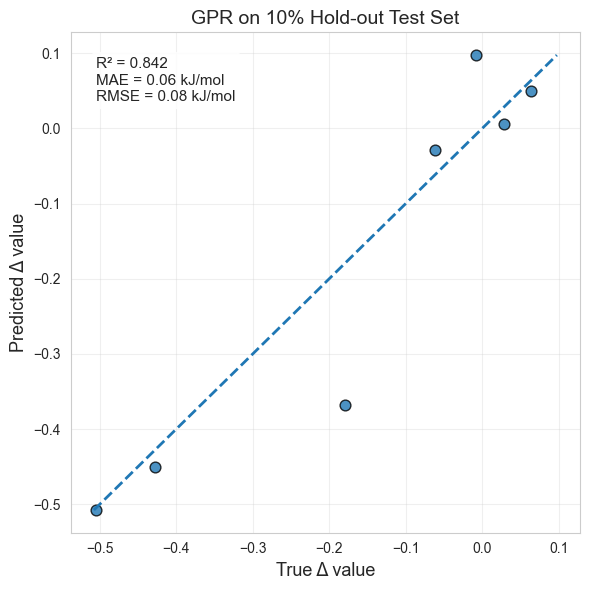

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =========================
# 6) 可视化：10% test 真实值 vs 预测值
# =========================
plt.figure(figsize=(6, 6))

# 散点图
plt.scatter(
    y_test,
    y_test_hat,
    alpha=0.8,
    s=60,
    edgecolors='k'
)

# 画 y = x 参考线
min_val = min(y_test.min(), y_test_hat.min())
max_val = max(y_test.max(), y_test_hat.max())
plt.plot([min_val, max_val], [min_val, max_val], '--', linewidth=2)

# 坐标轴
plt.xlabel("True Δ value", fontsize=13)
plt.ylabel("Predicted Δ value", fontsize=13)
plt.title("GPR on 10% Hold-out Test Set", fontsize=14)

# 坐标范围
plt.xlim(min_val - 0.05*(max_val-min_val), max_val + 0.05*(max_val-min_val))
plt.ylim(min_val - 0.05*(max_val-min_val), max_val + 0.05*(max_val-min_val))

# 显示指标
textstr = '\n'.join((
    f'R² = {test_r2:.3f}',
    f'MAE = {test_mae:.2f} kJ/mol',
    f'RMSE = {test_rmse:.2f} kJ/mol'
))
plt.text(
    0.05, 0.95, textstr,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
data_low

,ID,es1_ev,fs1,et1_ev,delta_est_ev,min_abs_s1_tn_ev,d_index_ang,t_index_ang,smiles,morgan_fp_with_freq,delta_es1_pred,es1_ev_high_pred
0,1,1.8680,1.348143,1.3250,0.5430,0.0320,1.265,-0.559,FC(C(F)=C(C1=NSN=C12)C3=CC=C(C4=CC=C(N(C(C=C5)...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.146339,1.721661
1,2,2.9974,0.837642,2.2907,0.7067,0.1697,10.251,0.135,FC(C(F)=C(C1=NSN=C12)C3=CC(CC(CCCC)CC)=C(C4=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-1.215264,1.782136
2,3,2.4095,0.778946,1.3521,1.0574,0.1268,12.881,5.069,O=C1C(C2=C(C3=CC=C(C4=CC=C(N(C5=CC=CC=C5)C6=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",-0.348085,2.061415
3,4,2.4032,0.618219,1.2979,1.1053,0.0852,7.942,0.808,O=C1C(C2=C(/C=C/C3=CC=C(N(C4=CC=CC=C4)C5=CC=CC...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.360496,2.042704
4,5,2.3973,0.583616,1.2763,1.1210,0.1155,11.190,5.608,O=C1C(C2=C(/C=C/C3=CC=C(C=C3)/C(C4=CC=CC=C4)=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.518892,1.878408
...,...,...,...,...,...,...,...,...,...,...,...,...
627,629,2.4056,0.603487,1.3689,1.0367,0.1172,5.362,0.145,O=C1N(CC(C)C)C(C2=CC=C(S2)C3=CC=C(C=C3)N(C4=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",-0.179292,2.226308
628,630,2.3145,0.235426,1.2696,1.0449,0.1074,1.890,-3.945,CC1=CC=C(C=C1)N(C2=CC=C(C)C=C2)C3=CC=C(C=C3)C4...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-1.262941,1.051559
629,631,2.0000,0.234473,1.2056,0.7944,0.3562,1.224,-1.151,C1(C2=C(C=CC=C3)C3=C(N(C4=CC=C(N(C5=CC=CC=C5)C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-1.023360,0.976640
630,632,2.0288,0.276562,1.2906,0.7382,0.2764,10.349,4.781,C1(C2=C(C=CC=C3)C3=C(N(C(C=C4)=CC=C4/C(C5=CC=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.963968,1.064832


In [25]:
fp_low = np.array(data_low["morgan_fp_with_freq"].tolist(), dtype=float)
fp_low_top = fp_low[:, top_indices]
X_low = np.hstack([
    data_low["min_abs_s1_tn_ev"].values.astype(float).reshape(-1, 1),
    fp_low_top.astype(float)
])
X_low_s = final_scaler.transform(X_low)
delta_pred = final_gpr.predict(X_low_s)
data_low["delta_min_abs_s1_tn_ev_pred"] = delta_pred
data_low["min_abs_s1_tn_ev_high_pred"] = data_low["min_abs_s1_tn_ev"].astype(float) + data_low["delta_min_abs_s1_tn_ev_pred"].astype(float)

In [26]:
fp_es_new_300 = np.array(data_es_new_300["morgan_fp_with_freq"].tolist(), dtype=float)
fp_es_new_300_top = fp_es_new_300[:, top_indices]
X_es_new_300 = np.hstack([
    data_es_new_300["min_abs_s1_tn_ev"].values.astype(float).reshape(-1, 1),
    fp_es_new_300_top.astype(float)
])
X_es_new_300_s = final_scaler.transform(X_es_new_300)
delta_pred = final_gpr.predict(X_es_new_300_s)
data_es_new_300["delta_min_abs_s1_tn_ev_pred"] = delta_pred
data_es_new_300["min_abs_s1_tn_ev_high_pred"] = data_es_new_300["min_abs_s1_tn_ev"].astype(float) + data_es_new_300["delta_min_abs_s1_tn_ev_pred"].astype(float)

In [27]:
# 定义你要筛选的 mol_id 列表
target_ids = [28, 88, 139]

# 定义你需要提取的列名
target_columns = ['ID', 'SMILES',
    'min_abs_s1_tn_ev_high_pred']

# 使用 .loc 进行精确的行筛选和列提取（推荐写法，效率高且规范）
result_df = data_es_new_300.loc[data_es_new_300['ID'].isin(target_ids), target_columns]

# 查看结果
result_df

,ID,SMILES,min_abs_s1_tn_ev_high_pred
27,28,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,-0.046766
87,88,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,-0.094748
138,139,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,-0.062967


In [32]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


data_es_new_300 = data_es_new_300.dropna(subset=["morgan_fp_with_freq"]).reset_index(drop=True)

# =========================
# 1) 基础数据
# =========================
fingerprints_all = np.array(df["morgan_fp_with_freq"].tolist(), dtype=float)
y_all = df["delta_min_abs_s1_tn"].values.astype(float)
et1_low_all = df["min_abs_s1_tn_ev_low"].values.astype(float)

fp_es_new_300 = np.array(data_es_new_300["morgan_fp_with_freq"].tolist(), dtype=float)

target_ids = [28, 88, 139]
target_columns = ["ID", "SMILES", "min_abs_s1_tn_ev_high_pred"]

# =========================
# 2) GPR kernel
# =========================
kernel = (
    C(1.0, (1e-2, 1e2)) *
    RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) +
    WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))
)

# =========================
# 3) 遍历 seed = 0~100
# =========================
all_seed_results = []
valid_seeds = []

for seed in range(5000, 15000):

    # -------------------------
    # 90/10 split
    # -------------------------
    idx = np.arange(len(df))
    train_idx, test_idx = train_test_split(
        idx,
        test_size=0.10,
        random_state=seed,
        shuffle=True
    )

    fp_train_full = fingerprints_all[train_idx]
    fp_test = fingerprints_all[test_idx]

    y_train_full = y_all[train_idx]
    y_test = y_all[test_idx]

    et1_train_full = et1_low_all[train_idx]
    et1_test = et1_low_all[test_idx]

    # -------------------------
    # 只用 train 计算 top_indices
    # -------------------------
    nonzero_frequency = np.count_nonzero(fp_train_full, axis=0) / fp_train_full.shape[0]
    top_indices = np.argsort(nonzero_frequency)[-100:]

    fp_train_top_full = fp_train_full[:, top_indices]
    fp_test_top = fp_test[:, top_indices]

    X_train_full = np.hstack([
        et1_train_full.reshape(-1, 1),
        fp_train_top_full
    ])

    X_test = np.hstack([
        et1_test.reshape(-1, 1),
        fp_test_top
    ])

    # -------------------------
    # 训练最终模型
    # -------------------------
    final_scaler = StandardScaler()
    X_train_full_s = final_scaler.fit_transform(X_train_full)

    final_gpr = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
    )

    final_gpr.fit(X_train_full_s, y_train_full)

    # -------------------------
    # 10% test performance
    # -------------------------
    X_test_s = final_scaler.transform(X_test)
    y_test_hat = final_gpr.predict(X_test_s)

    test_mae = mean_absolute_error(y_test, y_test_hat)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_hat))
    test_r2 = r2_score(y_test, y_test_hat)

    # -------------------------
    # 对 data_es_new_300 预测
    # -------------------------
    fp_es_new_300_top = fp_es_new_300[:, top_indices]

    X_es_new_300 = np.hstack([
        data_es_new_300["min_abs_s1_tn_ev"].values.astype(float).reshape(-1, 1),
        fp_es_new_300_top.astype(float)
    ])

    X_es_new_300_s = final_scaler.transform(X_es_new_300)

    delta_pred = final_gpr.predict(X_es_new_300_s)

    temp_pred_df = data_es_new_300.copy()
    temp_pred_df["delta_min_abs_s1_tn_ev_pred"] = delta_pred
    temp_pred_df["min_abs_s1_tn_ev_high_pred"] = (
        temp_pred_df["min_abs_s1_tn_ev"].astype(float)
        + temp_pred_df["delta_min_abs_s1_tn_ev_pred"].astype(float)
    )

    result_df = temp_pred_df.loc[
        temp_pred_df["ID"].isin(target_ids),
        ["ID", "SMILES", "min_abs_s1_tn_ev_high_pred"]
    ].copy()

    # -------------------------
    # 判断三个目标是否都 > 0
    # -------------------------
    all_three_positive = (
        len(result_df) == len(target_ids)
        and (result_df["min_abs_s1_tn_ev_high_pred"] > 0).all()
    )

    if all_three_positive:
        valid_seeds.append(seed)

    # -------------------------
    # 保存当前 seed 的结果
    # -------------------------
    row = {
        "seed": seed,
        "test_MAE": test_mae,
        "test_RMSE": test_rmse,
        "test_R2": test_r2,
        "all_three_positive": all_three_positive
    }

    for _, r in result_df.iterrows():
        mol_id = int(r["ID"])
        row[f"ID_{mol_id}_high_pred"] = r["min_abs_s1_tn_ev_high_pred"]

    all_seed_results.append(row)

# =========================
# 4) 汇总结果
# =========================
seed_result_df = pd.DataFrame(all_seed_results)

print("Seeds where all three molecules have min_abs_s1_tn_ev_high_pred > 0:")
print(valid_seeds)

print("\nDetailed results:")
display(seed_result_df)

d:\miniconda3\envs\mygpt\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\miniconda3\envs\mygpt\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\miniconda3\envs\mygpt\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\miniconda3\envs\mygpt\Lib\site-packages\sklearn\gaussian_process\ke

Seeds where all three molecules have min_abs_s1_tn_ev_high_pred > 0:
[]

Detailed results:


,seed,test_MAE,test_RMSE,test_R2,all_three_positive,ID_28_high_pred,ID_88_high_pred,ID_139_high_pred
0,5000,0.060994,0.066565,0.319755,False,-0.064713,-0.140978,-0.094940
1,5001,0.038993,0.050960,0.915407,False,-0.096072,-0.143785,-0.097774
2,5002,0.056973,0.062834,-0.184822,False,-0.103394,-0.108494,-0.066704
3,5003,0.064754,0.076185,-0.027312,False,-0.147225,-0.180472,-0.142787
4,5004,0.021216,0.027238,0.968410,False,-0.098215,-0.143837,-0.106565
...,...,...,...,...,...,...,...,...
9995,14995,0.035955,0.043204,0.631129,False,-0.058411,-0.078992,-0.029278
9996,14996,0.065174,0.085733,0.561531,False,-0.054276,-0.129760,-0.088253
9997,14997,0.063472,0.069218,0.250591,False,0.011829,-0.099065,-0.028542
9998,14998,0.046243,0.057866,0.842988,False,-0.082154,-0.119428,-0.065471


In [36]:
seed_result_df

,seed,test_MAE,test_RMSE,test_R2,all_three_positive,ID_28_high_pred,ID_88_high_pred,ID_139_high_pred
0,5000,0.060994,0.066565,0.319755,False,-0.064713,-0.140978,-0.094940
1,5001,0.038993,0.050960,0.915407,False,-0.096072,-0.143785,-0.097774
2,5002,0.056973,0.062834,-0.184822,False,-0.103394,-0.108494,-0.066704
3,5003,0.064754,0.076185,-0.027312,False,-0.147225,-0.180472,-0.142787
4,5004,0.021216,0.027238,0.968410,False,-0.098215,-0.143837,-0.106565
...,...,...,...,...,...,...,...,...
9995,14995,0.035955,0.043204,0.631129,False,-0.058411,-0.078992,-0.029278
9996,14996,0.065174,0.085733,0.561531,False,-0.054276,-0.129760,-0.088253
9997,14997,0.063472,0.069218,0.250591,False,0.011829,-0.099065,-0.028542
9998,14998,0.046243,0.057866,0.842988,False,-0.082154,-0.119428,-0.065471


In [37]:
cols = ["ID_28_high_pred", "ID_88_high_pred", "ID_139_high_pred"]

seed_result_df_selected = seed_result_df[
    (seed_result_df[cols] > 0).sum(axis=1) >= 1
].copy()

#### 5.2 linear model

In [42]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# =========================
# 0) Morgan fingerprint with frequency
# =========================
def get_Morgan_fingerprint_frequency(smi, radius=3, nBits=2048):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        info = {}
        _ = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits, bitInfo=info)
        keys = list(info.keys())
        frq = [len(v) for v in info.values()]
        mff = [0] * nBits
        for k, v in zip(keys, frq):
            mff[k] = v
        return mff
    except:
        return None


# =========================
# 1) 准备数据：df 必须有 smiles, min_abs_s1_tn_ev_low, delta_min_abs_s1_tn
# =========================
df["morgan_fp_with_freq"] = df["smiles"].apply(get_Morgan_fingerprint_frequency)
df = df.dropna(subset=["morgan_fp_with_freq"]).reset_index(drop=True)

fingerprints_all = np.array(df["morgan_fp_with_freq"].tolist(), dtype=float)

y_all = df["delta_min_abs_s1_tn"].values.astype(float)
et1_low_all = df["min_abs_s1_tn_ev_low"].values.astype(float)


# =========================
# 2) 先做 90/10 split
# =========================
idx = np.arange(len(df))

train_idx, test_idx = train_test_split(
    idx,
    test_size=0.10,
    random_state=42,
    shuffle=True
)

fp_train_full = fingerprints_all[train_idx]
fp_test = fingerprints_all[test_idx]

y_train_full = y_all[train_idx]
y_test = y_all[test_idx]

et1_train_full = et1_low_all[train_idx]
et1_test = et1_low_all[test_idx]


# =========================
# 3) 只用 90% train 计算 top_indices，避免 test leakage
# =========================
nonzero_frequency = np.count_nonzero(fp_train_full, axis=0) / fp_train_full.shape[0]
top_indices = np.argsort(nonzero_frequency)[-100:]

fp_train_top_full = fp_train_full[:, top_indices]
fp_test_top = fp_test[:, top_indices]

X_train_full = np.hstack([
    et1_train_full.reshape(-1, 1),
    fp_train_top_full
])

X_test = np.hstack([
    et1_test.reshape(-1, 1),
    fp_test_top
])


# =========================
# 4) 在 90% train 上做 5-fold CV
# =========================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_true, cv_pred = [], []

for tr_i, va_i in kf.split(X_train_full):
    X_tr, X_va = X_train_full[tr_i], X_train_full[va_i]
    y_tr, y_va = y_train_full[tr_i], y_train_full[va_i]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_va_s = scaler.transform(X_va)

    model = LinearRegression()
    model.fit(X_tr_s, y_tr)

    y_hat = model.predict(X_va_s)

    cv_true.append(y_va)
    cv_pred.append(y_hat)

cv_true = np.concatenate(cv_true)
cv_pred = np.concatenate(cv_pred)

cv_mae = mean_absolute_error(cv_true, cv_pred)
cv_rmse = np.sqrt(mean_squared_error(cv_true, cv_pred))
cv_r2 = r2_score(cv_true, cv_pred)

print("===== 5-fold CV on 90% train =====")
print(f"MAE  = {cv_mae:.2f} kJ/mol")
print(f"RMSE = {cv_rmse:.2f} kJ/mol")
print(f"R²   = {cv_r2:.3f}")


# =========================
# 5) 用 90% train 全量训练最终线性模型
# =========================
final_scaler = StandardScaler()
X_train_full_s = final_scaler.fit_transform(X_train_full)

final_model = LinearRegression()
final_model.fit(X_train_full_s, y_train_full)

X_test_s = final_scaler.transform(X_test)
y_test_hat = final_model.predict(X_test_s)

test_mae = mean_absolute_error(y_test, y_test_hat)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_hat))
test_r2 = r2_score(y_test, y_test_hat)

print("\n===== Hold-out 10% Test (trained on 90%) =====")
print(f"MAE  = {test_mae:.2f} kJ/mol")
print(f"RMSE = {test_rmse:.2f} kJ/mol")
print(f"R²   = {test_r2:.3f}")


# =========================
# 6) 可选：保存模型、scaler 和 top_indices
# =========================
joblib.dump(final_model, "linear_delta_model.pkl")
joblib.dump(final_scaler, "linear_delta_scaler.pkl")
joblib.dump(top_indices, "linear_top_indices.pkl")

===== 5-fold CV on 90% train =====
MAE  = 0.11 kJ/mol
RMSE = 0.15 kJ/mol
R²   = -0.011

===== Hold-out 10% Test (trained on 90%) =====
MAE  = 0.08 kJ/mol
RMSE = 0.10 kJ/mol
R²   = 0.786


[20:03:51] DEPRECATION WARNING: please use MorganGenerator
[20:03:51] DEPRECATION WARNING: please use MorganGenerator
[20:03:51] DEPRECATION WARNING: please use MorganGenerator
[20:03:51] DEPRECATION WARNING: please use MorganGenerator
[20:03:51] DEPRECATION WARNING: please use MorganGenerator
[20:03:51] DEPRECATION WARNING: please use MorganGenerator
[20:03:51] DEPRECATION WARNING: please use MorganGenerator
[20:03:51] DEPRECATION WARNING: please use MorganGenerator
[20:03:51] DEPRECATION WARNING: please use MorganGenerator
[20:03:51] DEPRECATION WARNING: please use MorganGenerator
[20:03:51] DEPRECATION WARNING: please use MorganGenerator
[20:03:51] DEPRECATION WARNING: please use MorganGenerator
[20:03:51] DEPRECATION WARNING: please use MorganGenerator
[20:03:51] DEPRECATION WARNING: please use MorganGenerator
[20:03:51] DEPRECATION WARNING: please use MorganGenerator
[20:03:51] DEPRECATION WARNING: please use MorganGenerator
[20:03:51] DEPRECATION WARNING: please use MorganGenerat

['linear_top_indices.pkl']

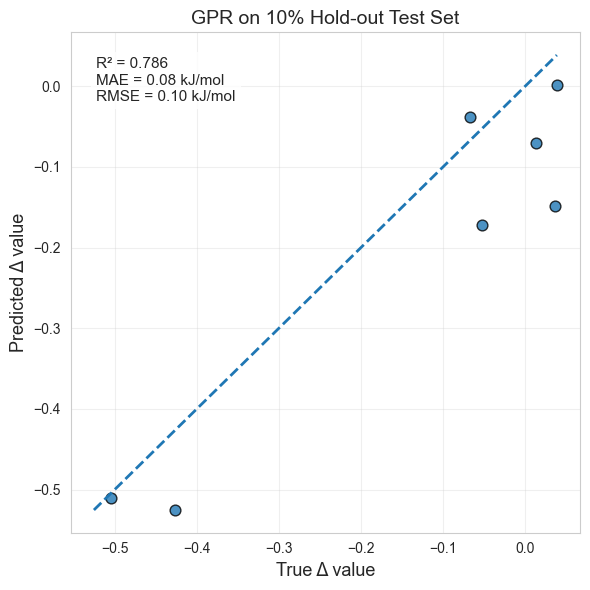

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =========================
# 6) 可视化：10% test 真实值 vs 预测值
# =========================
plt.figure(figsize=(6, 6))

# 散点图
plt.scatter(
    y_test,
    y_test_hat,
    alpha=0.8,
    s=60,
    edgecolors='k'
)

# 画 y = x 参考线
min_val = min(y_test.min(), y_test_hat.min())
max_val = max(y_test.max(), y_test_hat.max())
plt.plot([min_val, max_val], [min_val, max_val], '--', linewidth=2)

# 坐标轴
plt.xlabel("True Δ value", fontsize=13)
plt.ylabel("Predicted Δ value", fontsize=13)
plt.title("GPR on 10% Hold-out Test Set", fontsize=14)

# 坐标范围
plt.xlim(min_val - 0.05*(max_val-min_val), max_val + 0.05*(max_val-min_val))
plt.ylim(min_val - 0.05*(max_val-min_val), max_val + 0.05*(max_val-min_val))

# 显示指标
textstr = '\n'.join((
    f'R² = {test_r2:.3f}',
    f'MAE = {test_mae:.2f} kJ/mol',
    f'RMSE = {test_rmse:.2f} kJ/mol'
))
plt.text(
    0.05, 0.95, textstr,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
fp_es_new_300 = np.array(
    data_es_new_300["morgan_fp_with_freq"].tolist(),
    dtype=float
)

fp_es_new_300_top = fp_es_new_300[:, top_indices]

X_es_new_300 = np.hstack([
    data_es_new_300["min_abs_s1_tn_ev"].values.astype(float).reshape(-1, 1),
    fp_es_new_300_top.astype(float)
])

X_es_new_300_s = final_scaler.transform(X_es_new_300)

# 使用线性模型预测 delta
delta_pred = final_model.predict(X_es_new_300_s)

data_es_new_300["delta_min_abs_s1_tn_ev_pred"] = delta_pred

data_es_new_300["min_abs_s1_tn_ev_high_pred"] = (
    data_es_new_300["min_abs_s1_tn_ev"].astype(float)
    + data_es_new_300["delta_min_abs_s1_tn_ev_pred"].astype(float)
)

In [45]:
# 定义你要筛选的 mol_id 列表
target_ids = [28, 88, 139]

# 定义你需要提取的列名
target_columns = ['ID', 'SMILES',
    'min_abs_s1_tn_ev_high_pred']

# 使用 .loc 进行精确的行筛选和列提取（推荐写法，效率高且规范）
result_df = data_es_new_300.loc[data_es_new_300['ID'].isin(target_ids), target_columns]

# 查看结果
result_df

,ID,SMILES,min_abs_s1_tn_ev_high_pred
27,28,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,0.227204
87,88,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,-0.029955
138,139,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,0.024526


### 6. d_index

In [33]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# =========================
# 0) Morgan fingerprint with frequency
# =========================
def get_Morgan_fingerprint_frequency(smi, radius=3, nBits=2048):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        info = {}
        _ = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits, bitInfo=info)
        keys = list(info.keys())
        frq = [len(v) for v in info.values()]
        mff = [0] * nBits
        for k, v in zip(keys, frq):
            mff[k] = v
        return mff
    except:
        return None

# =========================
# 1) 准备数据：df 必须有 smiles, et1_KJmol_low, delta_et1
# =========================
df["morgan_fp_with_freq"] = df["smiles"].apply(get_Morgan_fingerprint_frequency)
df = df.dropna(subset=["morgan_fp_with_freq"]).reset_index(drop=True)

# 统一成 numpy（避免 list/None）
fingerprints_all = np.array(df["morgan_fp_with_freq"].tolist(), dtype=float)
y_all = df["delta_d_index"].values.astype(float)
et1_low_all = df["d_index_ang_low"].values.astype(float)

# =========================
# 2) 先做 90/10 split（test 永远不参与特征选择 & 训练）
# =========================
idx = np.arange(len(df))
train_idx, test_idx = train_test_split(
    idx,
    test_size=0.10,
    random_state=42,
    shuffle=True
)

fp_train_full = fingerprints_all[train_idx]
fp_test = fingerprints_all[test_idx]

y_train_full = y_all[train_idx]
y_test = y_all[test_idx]

et1_train_full = et1_low_all[train_idx]
et1_test = et1_low_all[test_idx]

# =========================
# 3) 只用 90% train 计算 top_indices（避免 test leakage）
# =========================
nonzero_frequency = np.count_nonzero(fp_train_full, axis=0) / fp_train_full.shape[0]
top_indices = np.argsort(nonzero_frequency)[-100:]   # top100

# 组装 train_full / test 的特征
fp_train_top_full = fp_train_full[:, top_indices]
fp_test_top = fp_test[:, top_indices]

X_train_full = np.hstack([et1_train_full.reshape(-1, 1), fp_train_top_full])
X_test = np.hstack([et1_test.reshape(-1, 1), fp_test_top])

# =========================
# 4) 在 90% train 上做 5-fold CV（每折：fit scaler+gpr → predict）
# =========================
kernel = (
    C(1.0, (1e-2, 1e2)) *
    RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) +
    WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_true, cv_pred = [], []

for tr_i, va_i in kf.split(X_train_full):
    X_tr, X_va = X_train_full[tr_i], X_train_full[va_i]
    y_tr, y_va = y_train_full[tr_i], y_train_full[va_i]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_va_s = scaler.transform(X_va)

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
    )

    gpr.fit(X_tr_s, y_tr)
    y_hat = gpr.predict(X_va_s)

    cv_true.append(y_va)
    cv_pred.append(y_hat)

cv_true = np.concatenate(cv_true)
cv_pred = np.concatenate(cv_pred)

cv_mae = mean_absolute_error(cv_true, cv_pred)
cv_rmse = np.sqrt(mean_squared_error(cv_true, cv_pred))
cv_r2 = r2_score(cv_true, cv_pred)

print("===== 5-fold CV on 90% train =====")
print(f"MAE  = {cv_mae:.2f} kJ/mol")
print(f"RMSE = {cv_rmse:.2f} kJ/mol")
print(f"R²   = {cv_r2:.3f}")

# =========================
# 5) 用 90% train 全量训练最终模型（scaler + gpr）
# =========================
final_scaler = StandardScaler()
X_train_full_s = final_scaler.fit_transform(X_train_full)

final_gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)
final_gpr.fit(X_train_full_s, y_train_full)

# 在 10% test 上做一次最终评估（完全独立）
X_test_s = final_scaler.transform(X_test)
y_test_hat = final_gpr.predict(X_test_s)

test_mae = mean_absolute_error(y_test, y_test_hat)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_hat))
test_r2 = r2_score(y_test, y_test_hat)

print("\n===== Hold-out 10% Test (trained on 90%) =====")
print(f"MAE  = {test_mae:.2f} kJ/mol")
print(f"RMSE = {test_rmse:.2f} kJ/mol")
print(f"R²   = {test_r2:.3f}")


[13:28:51] DEPRECATION WARNING: please use MorganGenerator
[13:28:51] DEPRECATION WARNING: please use MorganGenerator
[13:28:51] DEPRECATION WARNING: please use MorganGenerator
[13:28:51] DEPRECATION WARNING: please use MorganGenerator
[13:28:51] DEPRECATION WARNING: please use MorganGenerator
[13:28:51] DEPRECATION WARNING: please use MorganGenerator
[13:28:51] DEPRECATION WARNING: please use MorganGenerator
[13:28:51] DEPRECATION WARNING: please use MorganGenerator
[13:28:51] DEPRECATION WARNING: please use MorganGenerator
[13:28:51] DEPRECATION WARNING: please use MorganGenerator
[13:28:51] DEPRECATION WARNING: please use MorganGenerator
[13:28:51] DEPRECATION WARNING: please use MorganGenerator
[13:28:51] DEPRECATION WARNING: please use MorganGenerator
[13:28:51] DEPRECATION WARNING: please use MorganGenerator
[13:28:51] DEPRECATION WARNING: please use MorganGenerator
[13:28:51] DEPRECATION WARNING: please use MorganGenerator
[13:28:51] DEPRECATION WARNING: please use MorganGenerat

===== 5-fold CV on 90% train =====
MAE  = 3.99 kJ/mol
RMSE = 5.79 kJ/mol
R²   = 0.405

===== Hold-out 10% Test (trained on 90%) =====
MAE  = 2.78 kJ/mol
RMSE = 4.01 kJ/mol
R²   = 0.448


d:\miniconda3\envs\mygpt\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [34]:
data_low

,ID,es1_ev,fs1,et1_ev,delta_est_ev,min_abs_s1_tn_ev,d_index_ang,t_index_ang,smiles,morgan_fp_with_freq,delta_es1_pred,es1_ev_high_pred,delta_fs1_pred,fs1_high_pred,delta_et1_ev_pred,et1_ev_high_pred,delta_delta_est_ev_pred,delta_est_ev_high_pred,delta_min_abs_s1_tn_ev_pred,min_abs_s1_tn_ev_high_pred
0,1,1.8680,1.348143,1.3250,0.5430,0.0320,1.265,-0.559,FC(C(F)=C(C1=NSN=C12)C3=CC=C(C4=CC=C(N(C(C=C5)...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.146339,1.721661,-0.071055,1.277088,-0.164779,1.160221,0.021416,0.564416,0.023000,0.055000
1,2,2.9974,0.837642,2.2907,0.7067,0.1697,10.251,0.135,FC(C(F)=C(C1=NSN=C12)C3=CC(CC(CCCC)CC)=C(C4=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-1.215264,1.782136,0.139242,0.976884,-1.051100,1.239600,-0.164395,0.542305,-0.089700,0.080000
2,3,2.4095,0.778946,1.3521,1.0574,0.1268,12.881,5.069,O=C1C(C2=C(C3=CC=C(C4=CC=C(N(C5=CC=CC=C5)C6=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",-0.348085,2.061415,1.634317,2.413263,-0.380742,0.971358,0.033705,1.091105,-0.037800,0.089000
3,4,2.4032,0.618219,1.2979,1.1053,0.0852,7.942,0.808,O=C1C(C2=C(/C=C/C3=CC=C(N(C4=CC=CC=C4)C5=CC=CC...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.360496,2.042704,2.149588,2.767807,-0.491468,0.806432,0.134382,1.239682,0.012800,0.098000
4,5,2.3973,0.583616,1.2763,1.1210,0.1155,11.190,5.608,O=C1C(C2=C(/C=C/C3=CC=C(C=C3)/C(C4=CC=CC=C4)=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.518892,1.878408,0.746775,1.330391,-0.496972,0.779328,-0.021299,1.099701,-0.069947,0.045553
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627,629,2.4056,0.603487,1.3689,1.0367,0.1172,5.362,0.145,O=C1N(CC(C)C)C(C2=CC=C(S2)C3=CC=C(C=C3)N(C4=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",-0.179292,2.226308,1.885253,2.488740,-0.374395,0.994505,0.189037,1.225737,-0.137684,-0.020484
628,630,2.3145,0.235426,1.2696,1.0449,0.1074,1.890,-3.945,CC1=CC=C(C=C1)N(C2=CC=C(C)C=C2)C3=CC=C(C=C3)C4...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-1.262941,1.051559,-0.246472,-0.011046,-0.356616,0.912984,-0.914859,0.130041,-0.088439,0.018961
629,631,2.0000,0.234473,1.2056,0.7944,0.3562,1.224,-1.151,C1(C2=C(C=CC=C3)C3=C(N(C4=CC=C(N(C5=CC=CC=C5)C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-1.023360,0.976640,0.154207,0.388680,-0.699380,0.506220,-0.361842,0.432558,-0.221893,0.134307
630,632,2.0288,0.276562,1.2906,0.7382,0.2764,10.349,4.781,C1(C2=C(C=CC=C3)C3=C(N(C(C=C4)=CC=C4/C(C5=CC=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.963968,1.064832,0.151542,0.428104,-0.690723,0.599877,-0.307521,0.430679,-0.214447,0.061953


In [35]:
fp_low = np.array(data_low["morgan_fp_with_freq"].tolist(), dtype=float)
fp_low_top = fp_low[:, top_indices]
X_low = np.hstack([
    data_low["d_index_ang"].values.astype(float).reshape(-1, 1),
    fp_low_top.astype(float)
])
X_low_s = final_scaler.transform(X_low)
delta_pred = final_gpr.predict(X_low_s)
data_low["delta_d_index_ang_pred"] = delta_pred
data_low["d_index_ang_high_pred"] = data_low["d_index_ang"].astype(float) + data_low["delta_d_index_ang_pred"].astype(float)

In [36]:
fp_es_new_300 = np.array(data_es_new_300["morgan_fp_with_freq"].tolist(), dtype=float)
fp_es_new_300_top = fp_es_new_300[:, top_indices]
X_es_new_300 = np.hstack([
    data_es_new_300["d_index_ang"].values.astype(float).reshape(-1, 1),
    fp_es_new_300_top.astype(float)
])
X_es_new_300_s = final_scaler.transform(X_es_new_300)
delta_pred = final_gpr.predict(X_es_new_300_s)
data_es_new_300["delta_d_index_ang_pred"] = delta_pred
data_es_new_300["d_index_ang_high_pred"] = data_es_new_300["d_index_ang"].astype(float) + data_es_new_300["delta_d_index_ang_pred"].astype(float)

### 7. t_index

In [37]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# =========================
# 0) Morgan fingerprint with frequency
# =========================
def get_Morgan_fingerprint_frequency(smi, radius=3, nBits=2048):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        info = {}
        _ = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits, bitInfo=info)
        keys = list(info.keys())
        frq = [len(v) for v in info.values()]
        mff = [0] * nBits
        for k, v in zip(keys, frq):
            mff[k] = v
        return mff
    except:
        return None

# =========================
# 1) 准备数据：df 必须有 smiles, et1_KJmol_low, delta_et1
# =========================
df["morgan_fp_with_freq"] = df["smiles"].apply(get_Morgan_fingerprint_frequency)
df = df.dropna(subset=["morgan_fp_with_freq"]).reset_index(drop=True)

# 统一成 numpy（避免 list/None）
fingerprints_all = np.array(df["morgan_fp_with_freq"].tolist(), dtype=float)
y_all = df["delta_t_index"].values.astype(float)
t_index_low_all = df["t_index_ang_low"].values.astype(float)

# =========================
# 2) 先做 90/10 split（test 永远不参与特征选择 & 训练）
# =========================
idx = np.arange(len(df))
train_idx, test_idx = train_test_split(
    idx,
    test_size=0.10,
    random_state=42,
    shuffle=True
)

fp_train_full = fingerprints_all[train_idx]
fp_test = fingerprints_all[test_idx]

y_train_full = y_all[train_idx]
y_test = y_all[test_idx]

t_index_train_full = t_index_low_all[train_idx]
t_index_test = t_index_low_all[test_idx]

# =========================
# 3) 只用 90% train 计算 top_indices（避免 test leakage）
# =========================
nonzero_frequency = np.count_nonzero(fp_train_full, axis=0) / fp_train_full.shape[0]
top_indices = np.argsort(nonzero_frequency)[-100:]   # top100

# 组装 train_full / test 的特征
fp_train_top_full = fp_train_full[:, top_indices]
fp_test_top = fp_test[:, top_indices]

X_train_full = np.hstack([t_index_train_full.reshape(-1, 1), fp_train_top_full])
X_test = np.hstack([t_index_test.reshape(-1, 1), fp_test_top])

# =========================
# 4) 在 90% train 上做 5-fold CV（每折：fit scaler+gpr → predict）
# =========================
kernel = (
    C(1.0, (1e-2, 1e2)) *
    RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) +
    WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_true, cv_pred = [], []

for tr_i, va_i in kf.split(X_train_full):
    X_tr, X_va = X_train_full[tr_i], X_train_full[va_i]
    y_tr, y_va = y_train_full[tr_i], y_train_full[va_i]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_va_s = scaler.transform(X_va)

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
    )

    gpr.fit(X_tr_s, y_tr)
    y_hat = gpr.predict(X_va_s)

    cv_true.append(y_va)
    cv_pred.append(y_hat)

cv_true = np.concatenate(cv_true)
cv_pred = np.concatenate(cv_pred)

cv_mae = mean_absolute_error(cv_true, cv_pred)
cv_rmse = np.sqrt(mean_squared_error(cv_true, cv_pred))
cv_r2 = r2_score(cv_true, cv_pred)

print("===== 5-fold CV on 90% train =====")
print(f"MAE  = {cv_mae:.2f} kJ/mol")
print(f"RMSE = {cv_rmse:.2f} kJ/mol")
print(f"R²   = {cv_r2:.3f}")

# =========================
# 5) 用 90% train 全量训练最终模型（scaler + gpr）
# =========================
final_scaler = StandardScaler()
X_train_full_s = final_scaler.fit_transform(X_train_full)

final_gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)
final_gpr.fit(X_train_full_s, y_train_full)

# 在 10% test 上做一次最终评估（完全独立）
X_test_s = final_scaler.transform(X_test)
y_test_hat = final_gpr.predict(X_test_s)

test_mae = mean_absolute_error(y_test, y_test_hat)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_hat))
test_r2 = r2_score(y_test, y_test_hat)

print("\n===== Hold-out 10% Test (trained on 90%) =====")
print(f"MAE  = {test_mae:.2f} kJ/mol")
print(f"RMSE = {test_rmse:.2f} kJ/mol")
print(f"R²   = {test_r2:.3f}")


[13:29:02] DEPRECATION WARNING: please use MorganGenerator
[13:29:02] DEPRECATION WARNING: please use MorganGenerator
[13:29:02] DEPRECATION WARNING: please use MorganGenerator
[13:29:02] DEPRECATION WARNING: please use MorganGenerator
[13:29:02] DEPRECATION WARNING: please use MorganGenerator
[13:29:02] DEPRECATION WARNING: please use MorganGenerator
[13:29:02] DEPRECATION WARNING: please use MorganGenerator
[13:29:02] DEPRECATION WARNING: please use MorganGenerator
[13:29:02] DEPRECATION WARNING: please use MorganGenerator
[13:29:02] DEPRECATION WARNING: please use MorganGenerator
[13:29:02] DEPRECATION WARNING: please use MorganGenerator
[13:29:02] DEPRECATION WARNING: please use MorganGenerator
[13:29:02] DEPRECATION WARNING: please use MorganGenerator
[13:29:02] DEPRECATION WARNING: please use MorganGenerator
[13:29:02] DEPRECATION WARNING: please use MorganGenerator
[13:29:02] DEPRECATION WARNING: please use MorganGenerator
[13:29:02] DEPRECATION WARNING: please use MorganGenerat

===== 5-fold CV on 90% train =====
MAE  = 4.61 kJ/mol
RMSE = 6.56 kJ/mol
R²   = 0.153

===== Hold-out 10% Test (trained on 90%) =====
MAE  = 4.01 kJ/mol
RMSE = 5.69 kJ/mol
R²   = 0.154


In [38]:
data_low

,ID,es1_ev,fs1,et1_ev,delta_est_ev,min_abs_s1_tn_ev,d_index_ang,t_index_ang,smiles,morgan_fp_with_freq,...,delta_fs1_pred,fs1_high_pred,delta_et1_ev_pred,et1_ev_high_pred,delta_delta_est_ev_pred,delta_est_ev_high_pred,delta_min_abs_s1_tn_ev_pred,min_abs_s1_tn_ev_high_pred,delta_d_index_ang_pred,d_index_ang_high_pred
0,1,1.8680,1.348143,1.3250,0.5430,0.0320,1.265,-0.559,FC(C(F)=C(C1=NSN=C12)C3=CC=C(C4=CC=C(N(C(C=C5)...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,-0.071055,1.277088,-0.164779,1.160221,0.021416,0.564416,0.023000,0.055000,-0.591015,0.673985
1,2,2.9974,0.837642,2.2907,0.7067,0.1697,10.251,0.135,FC(C(F)=C(C1=NSN=C12)C3=CC(CC(CCCC)CC)=C(C4=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,0.139242,0.976884,-1.051100,1.239600,-0.164395,0.542305,-0.089700,0.080000,-7.056929,3.194071
2,3,2.4095,0.778946,1.3521,1.0574,0.1268,12.881,5.069,O=C1C(C2=C(C3=CC=C(C4=CC=C(N(C5=CC=CC=C5)C6=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",...,1.634317,2.413263,-0.380742,0.971358,0.033705,1.091105,-0.037800,0.089000,-12.757951,0.123049
3,4,2.4032,0.618219,1.2979,1.1053,0.0852,7.942,0.808,O=C1C(C2=C(/C=C/C3=CC=C(N(C4=CC=CC=C4)C5=CC=CC...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,2.149588,2.767807,-0.491468,0.806432,0.134382,1.239682,0.012800,0.098000,-7.105966,0.836034
4,5,2.3973,0.583616,1.2763,1.1210,0.1155,11.190,5.608,O=C1C(C2=C(/C=C/C3=CC=C(C=C3)/C(C4=CC=CC=C4)=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,0.746775,1.330391,-0.496972,0.779328,-0.021299,1.099701,-0.069947,0.045553,-10.589024,0.600976
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627,629,2.4056,0.603487,1.3689,1.0367,0.1172,5.362,0.145,O=C1N(CC(C)C)C(C2=CC=C(S2)C3=CC=C(C=C3)N(C4=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",...,1.885253,2.488740,-0.374395,0.994505,0.189037,1.225737,-0.137684,-0.020484,-5.715017,-0.353017
628,630,2.3145,0.235426,1.2696,1.0449,0.1074,1.890,-3.945,CC1=CC=C(C=C1)N(C2=CC=C(C)C=C2)C3=CC=C(C=C3)C4...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,-0.246472,-0.011046,-0.356616,0.912984,-0.914859,0.130041,-0.088439,0.018961,10.782973,12.672973
629,631,2.0000,0.234473,1.2056,0.7944,0.3562,1.224,-1.151,C1(C2=C(C=CC=C3)C3=C(N(C4=CC=C(N(C5=CC=CC=C5)C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,0.154207,0.388680,-0.699380,0.506220,-0.361842,0.432558,-0.221893,0.134307,2.662328,3.886328
630,632,2.0288,0.276562,1.2906,0.7382,0.2764,10.349,4.781,C1(C2=C(C=CC=C3)C3=C(N(C(C=C4)=CC=C4/C(C5=CC=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,0.151542,0.428104,-0.690723,0.599877,-0.307521,0.430679,-0.214447,0.061953,-3.518596,6.830404


In [39]:
fp_low = np.array(data_low["morgan_fp_with_freq"].tolist(), dtype=float)
fp_low_top = fp_low[:, top_indices]
X_low = np.hstack([
    data_low["t_index_ang"].values.astype(float).reshape(-1, 1),
    fp_low_top.astype(float)
])
X_low_s = final_scaler.transform(X_low)
delta_pred = final_gpr.predict(X_low_s)
data_low["delta_t_index_ang_pred"] = delta_pred
data_low["t_index_ang_high_pred"] = data_low["t_index_ang"].astype(float) + data_low["delta_t_index_ang_pred"].astype(float)

In [ ]:
#data_low.to_excel(r'D:\AI4polymer\cocrystal design\Data-0320\deltaML result\ES_data_low_with_prediction.xlsx', index=False)

In [41]:
fp_es_new_300 = np.array(data_es_new_300["morgan_fp_with_freq"].tolist(), dtype=float)
fp_es_new_300_top = fp_es_new_300[:, top_indices]
X_es_new_300 = np.hstack([
    data_es_new_300["t_index_ang"].values.astype(float).reshape(-1, 1),
    fp_es_new_300_top.astype(float)
])
X_es_new_300_s = final_scaler.transform(X_es_new_300)
delta_pred = final_gpr.predict(X_es_new_300_s)
data_es_new_300["delta_t_index_ang_pred"] = delta_pred
data_es_new_300["t_index_ang_high_pred"] = data_es_new_300["t_index_ang"].astype(float) + data_es_new_300["delta_t_index_ang_pred"].astype(float)

In [42]:
data_es_new_300.to_excel(r'D:\AI4polymer\cocrystal design\Data-0320\deltaML result\virtual_300\ES_data_new_300_with_prediction.xlsx', index=False)

In [43]:
# 定义你要筛选的 mol_id 列表
target_ids = [28, 88, 139]

# 定义你需要提取的列名
target_columns = ['ID', 'SMILES','es1_ev_high_pred',
    'fs1_high_pred',
    'et1_ev_high_pred',
    'delta_est_ev_high_pred',
    'min_abs_s1_tn_ev_high_pred',
    'd_index_ang_high_pred',
    't_index_ang_high_pred']

# 使用 .loc 进行精确的行筛选和列提取（推荐写法，效率高且规范）
result_df = data_es_new_300.loc[data_es_new_300['ID'].isin(target_ids), target_columns]

# 查看结果
result_df

,ID,SMILES,es1_ev_high_pred,fs1_high_pred,et1_ev_high_pred,delta_est_ev_high_pred,min_abs_s1_tn_ev_high_pred,d_index_ang_high_pred,t_index_ang_high_pred
27,28,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,1.151103,0.161072,1.386949,-0.100525,0.227204,15.568220,12.316836
87,88,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,1.250559,0.248283,1.011230,0.333078,-0.029955,18.248357,15.485188
138,139,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,1.041329,0.168225,0.939583,0.182430,0.024526,14.346270,9.648917


### 可视化

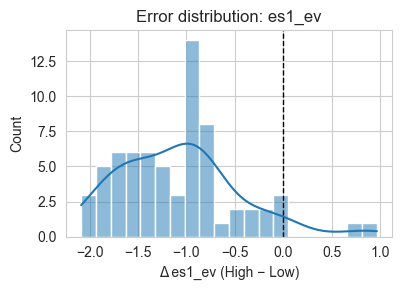

es1_ev: mean Δ = -1.080, std Δ = 0.624


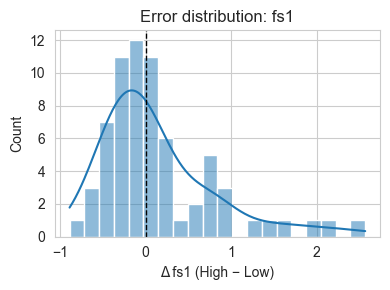

fs1: mean Δ = 0.141, std Δ = 0.681


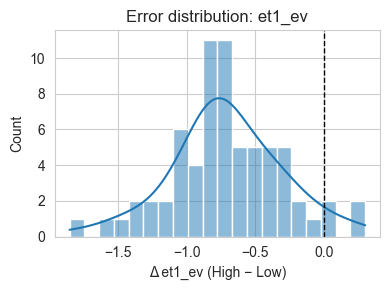

et1_ev: mean Δ = -0.710, std Δ = 0.407


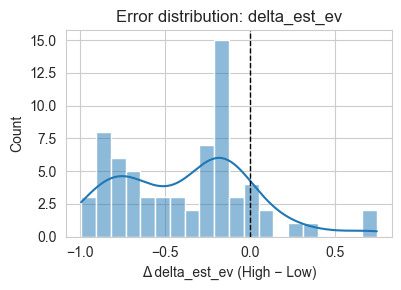

delta_est_ev: mean Δ = -0.370, std Δ = 0.390


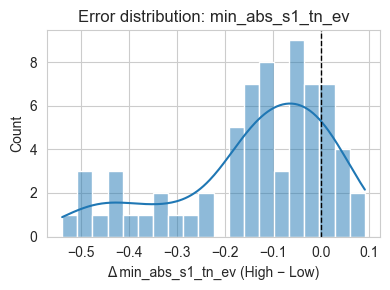

min_abs_s1_tn_ev: mean Δ = -0.140, std Δ = 0.160


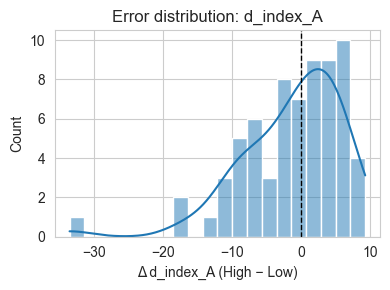

d_index_A: mean Δ = -1.383, std Δ = 7.377


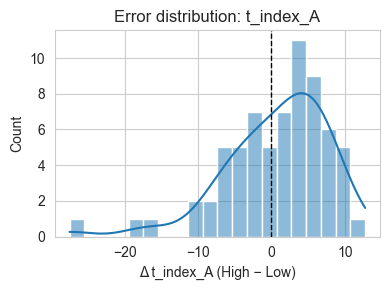

t_index_A: mean Δ = 0.668, std Δ = 7.131


In [25]:
for prop in properties:
    df[f'delta_{prop}'] = df[f'{prop}_high'] - df[f'{prop}_low']

    plt.figure(figsize=(4, 3))
    sns.histplot(df[f'delta_{prop}'], bins=20, kde=True)
    plt.axvline(0, color='k', linestyle='--', lw=1)
    
    plt.xlabel(f'Δ {prop} (High − Low)')
    plt.title(f'Error distribution: {prop}')
    plt.tight_layout()
    plt.show()

    print(
        f"{prop}: mean Δ = {df[f'delta_{prop}'].mean():.3f}, "
        f"std Δ = {df[f'delta_{prop}'].std():.3f}"
    )


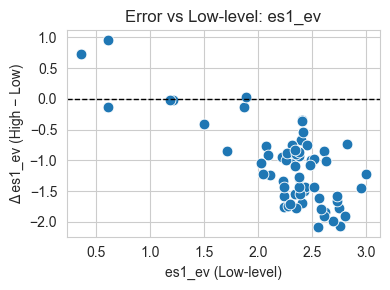

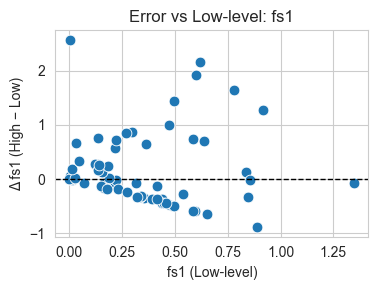

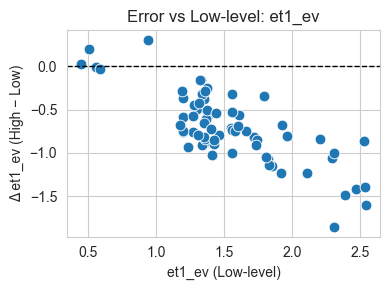

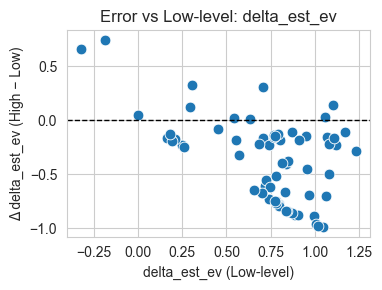

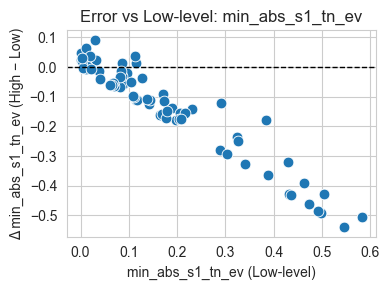

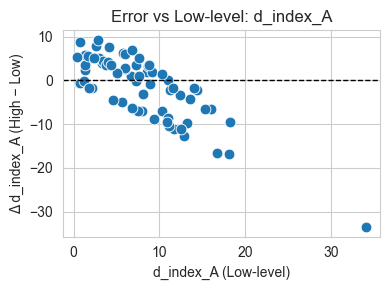

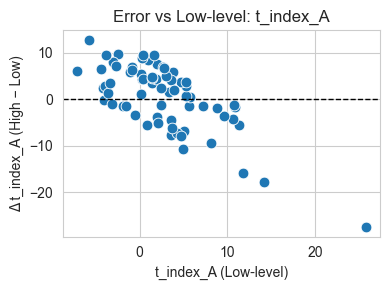

In [26]:
for prop in properties:
    plt.figure(figsize=(4, 3))
    sns.scatterplot(
        x=df[f'{prop}_low'],
        y=df[f'delta_{prop}'],
        s=60
    )
    plt.axhline(0, color='k', linestyle='--', lw=1)

    plt.xlabel(f'{prop} (Low-level)')
    plt.ylabel(f'Δ {prop} (High − Low)')
    plt.title(f'Error vs Low-level: {prop}')
    plt.tight_layout()
    plt.show()


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.linear_model import LinearRegression

for prop in properties:
    X = df[[f'{prop}_low']].values
    y = df[f'{prop}_high'].values

    lr = LinearRegression().fit(X, y)
    y_pred = lr.predict(X)

    mae = mean_absolute_error(y, y_pred)
    mse = mean_squared_error(y, y_pred)   # 不用 squared 参数
    rmse = np.sqrt(mse)

    print(f'\n{prop}')
    print(f'  y = {lr.coef_[0]:.3f} * x + {lr.intercept_:.3f}')
    print(f'  MAE = {mae:.3f}, RMSE = {rmse:.3f}')



es1_ev
  y = 0.076 * x + 1.018
  MAE = 0.354, RMSE = 0.416

fs1
  y = 0.959 * x + 0.155
  MAE = 0.501, RMSE = 0.675

et1_ev
  y = 0.306 * x + 0.357
  MAE = 0.199, RMSE = 0.248

delta_est_ev
  y = 0.363 * x + 0.097
  MAE = 0.292, RMSE = 0.330

min_abs_s1_tn_ev
  y = 0.032 * x + 0.038
  MAE = 0.034, RMSE = 0.043

d_index_A
  y = -0.027 * x + 6.571
  MAE = 3.886, RMSE = 4.376

t_index_A
  y = 0.047 * x + 3.165
  MAE = 4.415, RMSE = 4.907
